<a href="https://colab.research.google.com/github/jessicali23/229-Project/blob/main/colab_speech_emotion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Speech Emotion Recognition
**Before you start:** `Runtime → Change runtime type → T4 GPU`

Replicates the CNN-BiLSTM from: *Speech emotion recognition with light weight deep neural ensemble model using hand crafted features* (Nature, 2025)

1. Setup
2. Mount Google Drive
3. Download datasets
4. Explore the data
5. Feature extraction & augmentation (paper-exact)
6. **Model selection & training**
7. Evaluate & compare
8. Predict on your own audio

## 1. Setup
Run these cells once per session. Your project lives in Google Drive — no uploading needed after the first time.

In [1]:
import torch
print('GPU available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('Device:', torch.cuda.get_device_name(0))
else:
    print('No GPU — go to Runtime -> Change runtime type -> T4 GPU')

GPU available: True
Device: Tesla T4


In [2]:
import os, sys
from google.colab import drive

# ── Option A: Work from Google Drive (recommended) ────────────
# Avoids re-uploading every session. Set USE_DRIVE = False to upload instead.
USE_DRIVE = True

if USE_DRIVE:
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/speech_emotion'  # change if needed
    if not os.path.exists(PROJECT_DIR):
        print(f"Not found: {PROJECT_DIR}")
        print("Either update PROJECT_DIR above, or set USE_DRIVE = False to upload instead.")
    else:
        os.chdir(PROJECT_DIR)
        sys.path.insert(0, PROJECT_DIR)
        print("Ready:", os.getcwd())

# ── Option B: Upload zip each session ─────────────────────────
else:
    from google.colab import files
    import zipfile
    uploaded = files.upload()  # select speech_emotion_recognition.zip
    with zipfile.ZipFile(list(uploaded.keys())[0]) as z:
        z.extractall(".")
    os.chdir("speech_emotion")
    sys.path.insert(0, os.getcwd())
    print("Ready:", os.getcwd())


Mounted at /content/drive
Ready: /content/drive/MyDrive/speech_emotion


In [3]:
# ── ONE-TIME SETUP — run once to extract zip into Drive ───────
# 1. Upload speech_emotion_recognition.zip to drive.google.com
# 2. Run this cell — it extracts the project into Drive
# 3. After this, just set USE_DRIVE = True in the cell above
#    and update PROJECT_DIR if you extracted somewhere other than root

import zipfile, os
ZIP  = '/content/drive/MyDrive/speech_emotion_recognition.zip'  # change if needed
DEST = '/content/drive/MyDrive'

if os.path.exists(ZIP):
    with zipfile.ZipFile(ZIP, "r") as z:
        z.extractall(DEST)
    print("Done. Project extracted to", DEST + "/speech_emotion")
    print("From now on just use USE_DRIVE = True in the cell above.")
else:
    print("Zip not found at", ZIP)
    print("Upload speech_emotion_recognition.zip to your Drive root first.")


Done. Project extracted to /content/drive/MyDrive/speech_emotion
From now on just use USE_DRIVE = True in the cell above.


In [4]:
!pip install -q librosa==0.10.2 soundfile einops tensorboard scikit-learn
print('Dependencies installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.0/260.0 kB 20.1 MB/s eta 0:00:00
Dependencies installed


## 2. Mount Google Drive

In [3]:
from google.colab import drive
import os
CHECKPOINT_DIR = '/content/drive/MyDrive/speech_emotion_checkpoints'
RESULTS_DIR    = '/content/drive/MyDrive/speech_emotion_results'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR,    exist_ok=True)
print("Checkpoints ->", CHECKPOINT_DIR)
print("Results     ->", RESULTS_DIR)


Checkpoints -> /content/drive/MyDrive/speech_emotion_checkpoints
Results     -> /content/drive/MyDrive/speech_emotion_results


In [4]:
import os
if "CHECKPOINT_DIR" not in dir():
    CHECKPOINT_DIR = "./checkpoints"
    RESULTS_DIR    = "./results"
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    os.makedirs(RESULTS_DIR,    exist_ok=True)
    print("Using local storage (lost on restart)")


## 3. Download Datasets

In [7]:
!python data/download_datasets.py --datasets ravdess emodb --output_dir ./data/raw


  RAVDESS — Ryerson Audio-Visual Database of Emotional Speech and Song
  ravdess: 199MB [00:13, 15.6MB/s]               
  Extracting ravdess.zip …
  Extracted to data/raw/ravdess

  EMODB — Berlin Database of Emotional Speech
  emodb: 38.7MB [00:12, 3.28MB/s]                
  Extracting emodb.zip …
  Extracted to data/raw/emodb

Done. Dataset layout:
  data/raw/emodb
  data/raw/emodb.zip
  data/raw/ravdess
  data/raw/ravdess.zip


In [ ]:
# TESS — manual upload (download from https://tspace.library.utoronto.ca/handle/1807/24487)
UPLOAD_TESS = False   # set True if you have the zip
if UPLOAD_TESS:
    from google.colab import files
    import zipfile, os
    uploaded = files.upload()
    fname = list(uploaded.keys())[0]
    os.makedirs('./data/raw/tess', exist_ok=True)
    with zipfile.ZipFile(fname) as z:
        z.extractall('./data/raw/tess')
    print('TESS extracted')

In [4]:
import sys
sys.path.insert(0, '.')

# Paper trains on each dataset separately — choose one
DATASET = 'ravdess'   # 'ravdess' | 'emodb' | 'tess' | None for all

from data.dataset_loader import load_all_samples
datasets = [DATASET] if DATASET else None
samples  = load_all_samples('./data/raw', datasets=datasets)
#samples = load_all_samples('./data/raw', datasets=['ravdess', 'emodb'])
print(f'Total samples: {len(samples)}')

  ravdess: 1440 samples

Total: 1440 samples across 7 emotions
    angry       : 192
    disgust     : 192
    fear        : 192
    happy       : 192
    neutral     : 288
    sad         : 192
    surprised   : 192
Total samples: 1440


## 4. Explore the Data

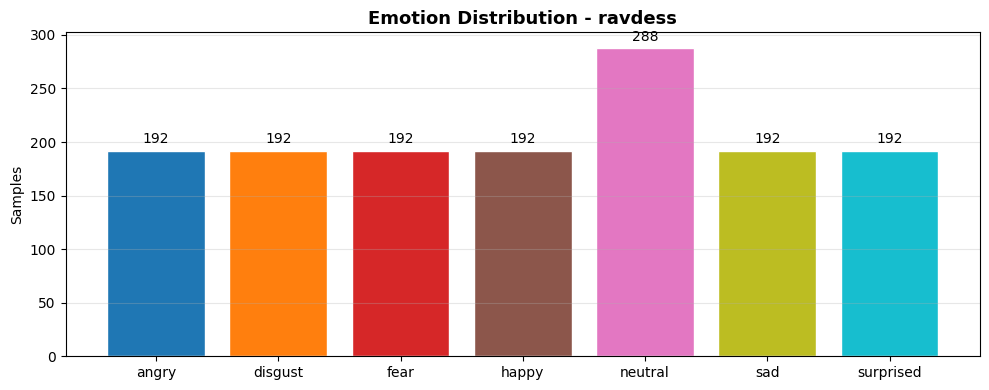

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter, defaultdict
from utils.config import EMOTIONS

label_dist = Counter(lbl for _, lbl in samples)
emotions   = [e for e in EMOTIONS if e in label_dist]
counts     = [label_dist[e] for e in emotions]

fig, ax = plt.subplots(figsize=(10, 4))
colors  = plt.cm.tab10(np.linspace(0, 1, len(emotions)))
bars    = ax.bar(emotions, counts, color=colors, edgecolor='white')
ax.bar_label(bars, padding=3)
ax.set_title(f'Emotion Distribution - {DATASET}', fontsize=13, fontweight='bold')
ax.set_ylabel('Samples')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

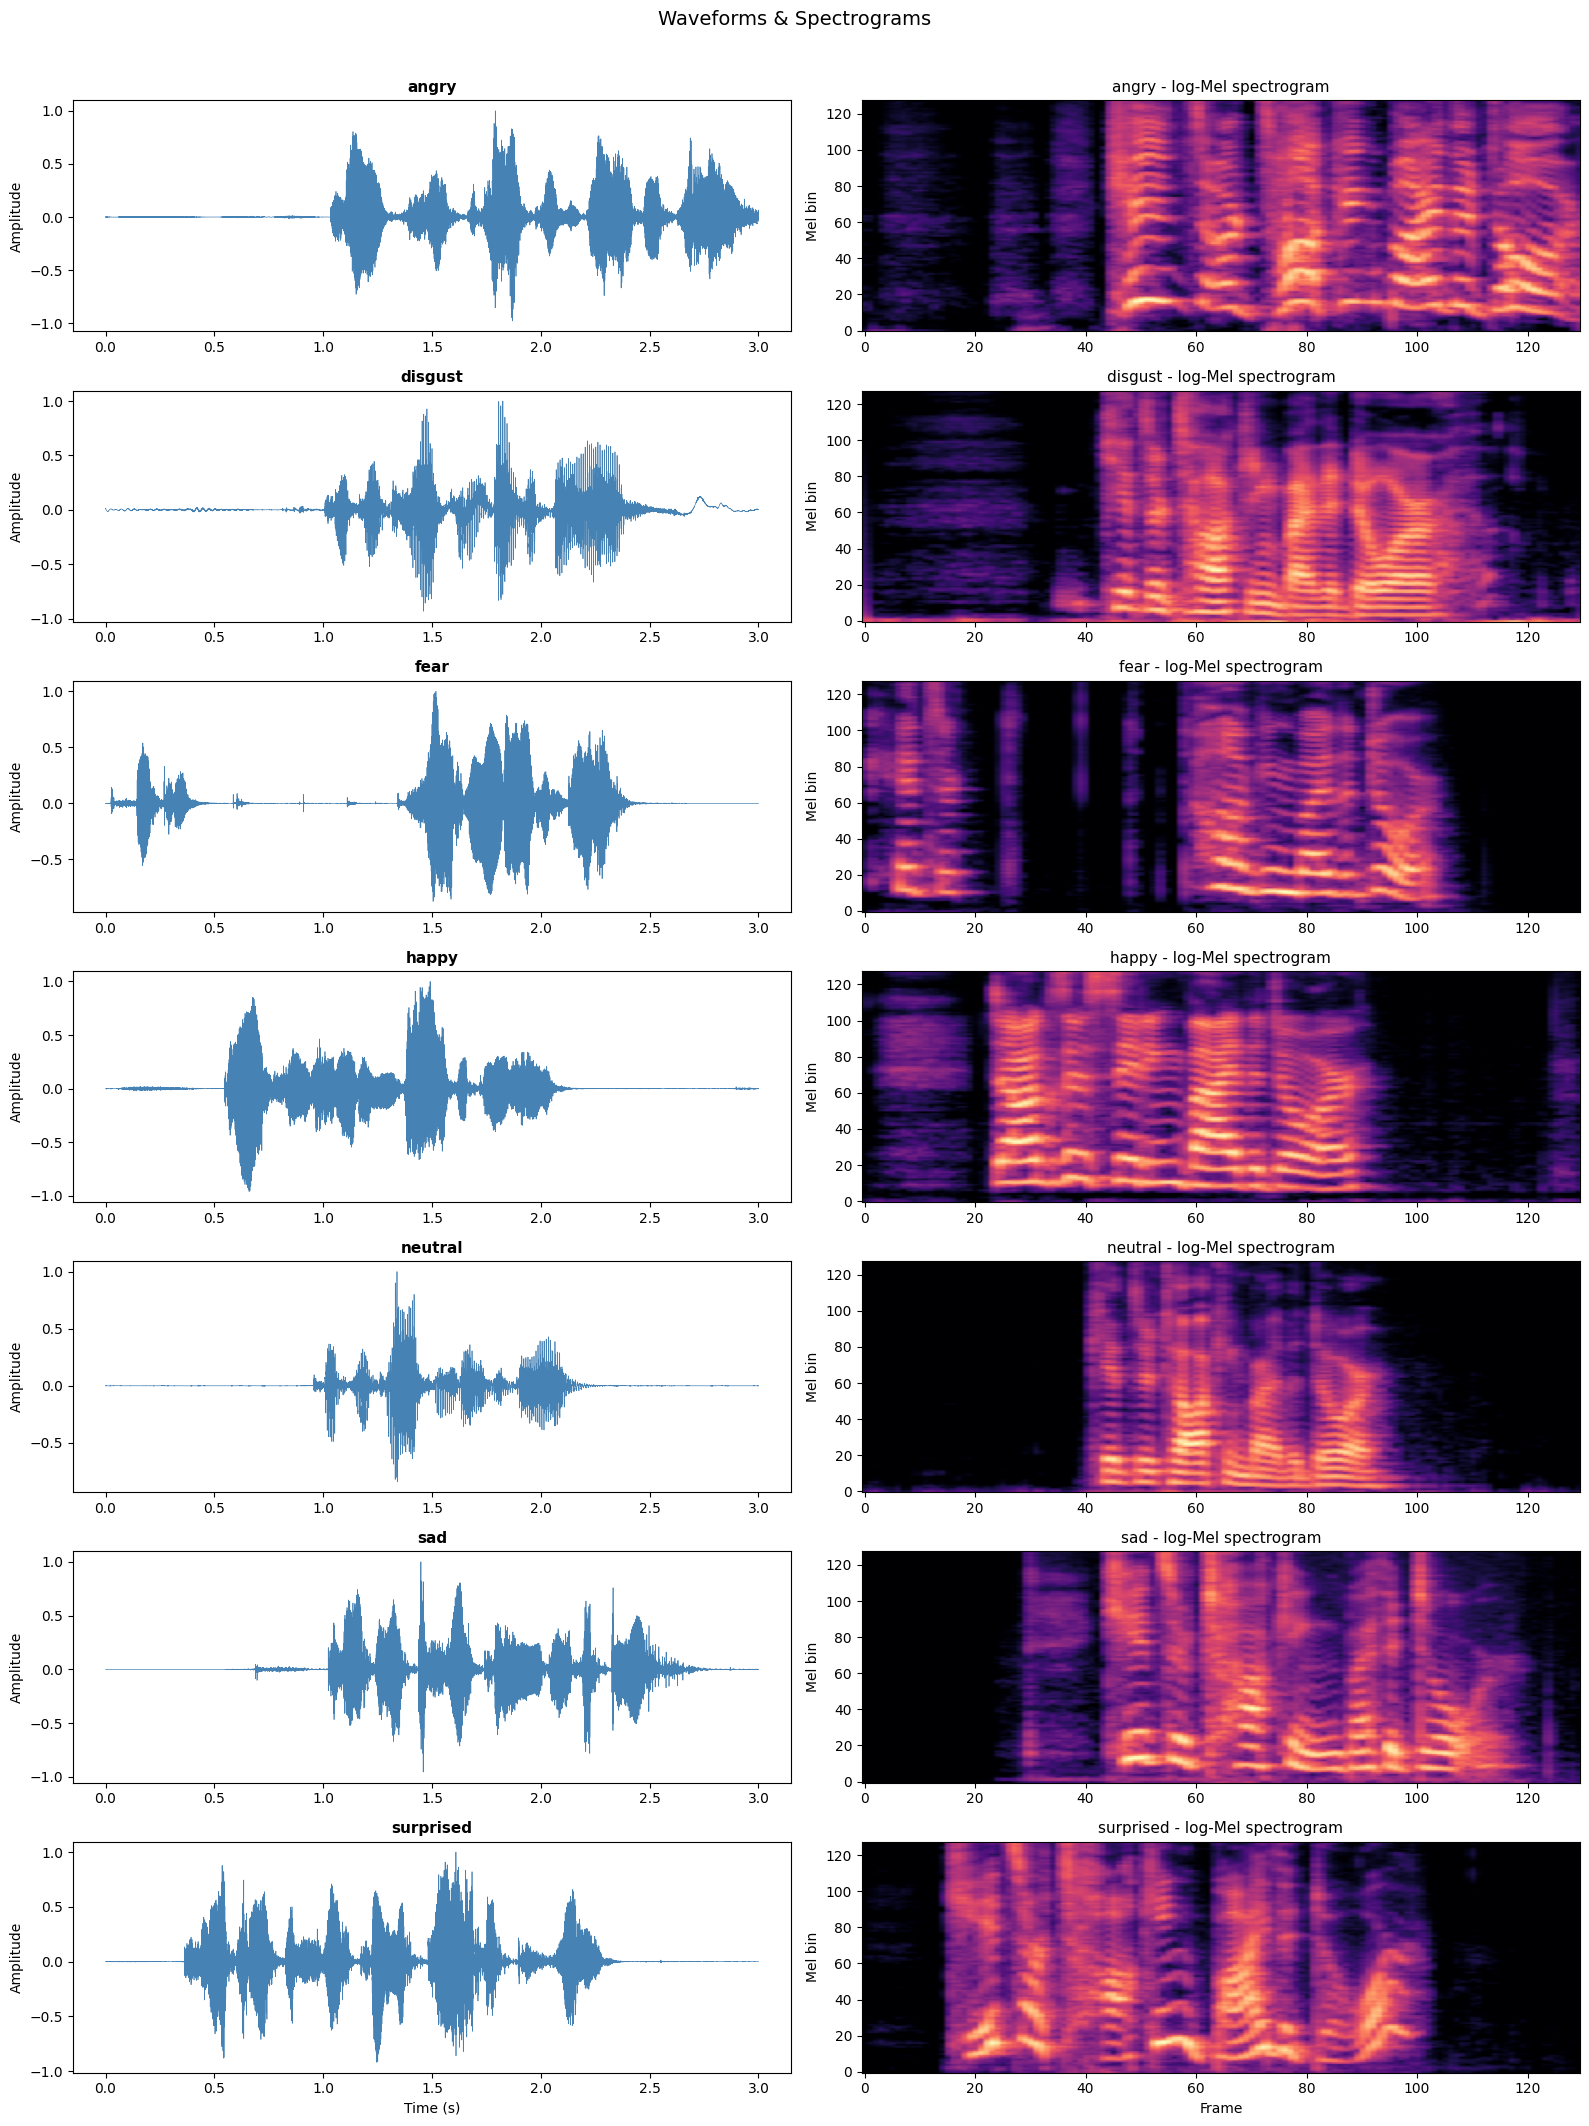

In [6]:
import librosa
from utils.audio_utils import load_audio, compute_melspectrogram
from utils.config import AUDIO_CFG

by_emotion = defaultdict(list)
for path, lbl in samples:
    by_emotion[lbl].append(path)

present = [e for e in EMOTIONS if e in by_emotion]
fig, axes = plt.subplots(len(present), 2, figsize=(16, 3 * len(present)))
if len(present) == 1: axes = [axes]

for i, emo in enumerate(present):
    y = load_audio(by_emotion[emo][0], AUDIO_CFG)
    S = compute_melspectrogram(y, AUDIO_CFG)
    t = np.linspace(0, len(y) / AUDIO_CFG.sample_rate, len(y))
    axes[i][0].plot(t, y, color='steelblue', lw=0.5)
    axes[i][0].set_title(emo, fontsize=11, fontweight='bold')
    axes[i][0].set_ylabel('Amplitude')
    axes[i][1].imshow(S, aspect='auto', origin='lower', cmap='magma')
    axes[i][1].set_title(f'{emo} - log-Mel spectrogram', fontsize=11)
    axes[i][1].set_ylabel('Mel bin')

axes[-1][0].set_xlabel('Time (s)')
axes[-1][1].set_xlabel('Frame')
plt.suptitle('Waveforms & Spectrograms', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Feature Extraction & Augmentation (Paper-Exact)
Replicates Figure 2:
- **(i) N.A.** Gaussian noise augmentation
- **(ii) P.A.** Pitch shift (factor=0.7)
- **(iii) N.A.+P.A.** Noise then pitch shift
- **(iv) O.A.** Original audio

Features: ZCR + RMSE + MFCC(40) + Chroma flattened to 1D vector, then StandardScaler

In [7]:
import numpy as np
import librosa

def load_and_pad(path, sr=22050, duration=2.5, offset=0.6):
    y, _ = librosa.load(path, sr=sr, duration=duration, offset=offset, mono=True)
    target = int(sr * duration)
    if len(y) < target:
        y = np.pad(y, (0, target - len(y)))
    return y[:target]

def extract_paper_features(y, sr=22050):
    zcr    = librosa.feature.zero_crossing_rate(y, frame_length=2048, hop_length=512).squeeze()
    rms    = librosa.feature.rms(y=y, frame_length=2048, hop_length=512).squeeze()
    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20, n_fft=2048, hop_length=512).flatten()
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=2048, hop_length=512).flatten()
    # Mean-aggregate mel to keep it compact: (128, T) -> (128,)
    mel    = np.mean(librosa.feature.melspectrogram(
                 y=y, sr=sr, n_fft=2048, hop_length=512), axis=1)
    feat   = np.concatenate([zcr, rms, mfcc, chroma, mel])
    return np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
"""
def extract_paper_features(y, sr=22050):
    mfcc   = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    chroma = np.mean(librosa.feature.chroma_stft(
                         S=np.abs(librosa.stft(y)), sr=sr).T, axis=0)
    mel    = np.mean(librosa.feature.melspectrogram(y=y, sr=sr).T, axis=0)
    feat   = np.hstack([mfcc, chroma, mel])
    return np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
"""
def augment_noise(y, noise_amp=0.035):
    noise = np.random.normal(0, 1, len(y))
    noise = noise / (np.max(np.abs(noise)) + 1e-8)
    return y + noise_amp * noise

def augment_pitch(y, sr=22050, pitch_factor=0.7):
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=pitch_factor)

def extract_all_augmentations(path, sr=22050):
    y      = load_and_pad(path, sr=sr)
    y_na   = augment_noise(y)
    y_pa   = augment_pitch(y, sr=sr)
    y_napa = augment_pitch(augment_noise(y), sr=sr)
    return (
        extract_paper_features(y_na,   sr),
        extract_paper_features(y_pa,   sr),
        extract_paper_features(y_napa, sr),
        extract_paper_features(y,      sr),
    )

# Sanity check
test_feats = extract_all_augmentations(samples[0][0])
print(f'Feature vector length: {test_feats[0].shape[0]}  (paper reports 3672)')

Feature vector length: 3800  (paper reports 3672)


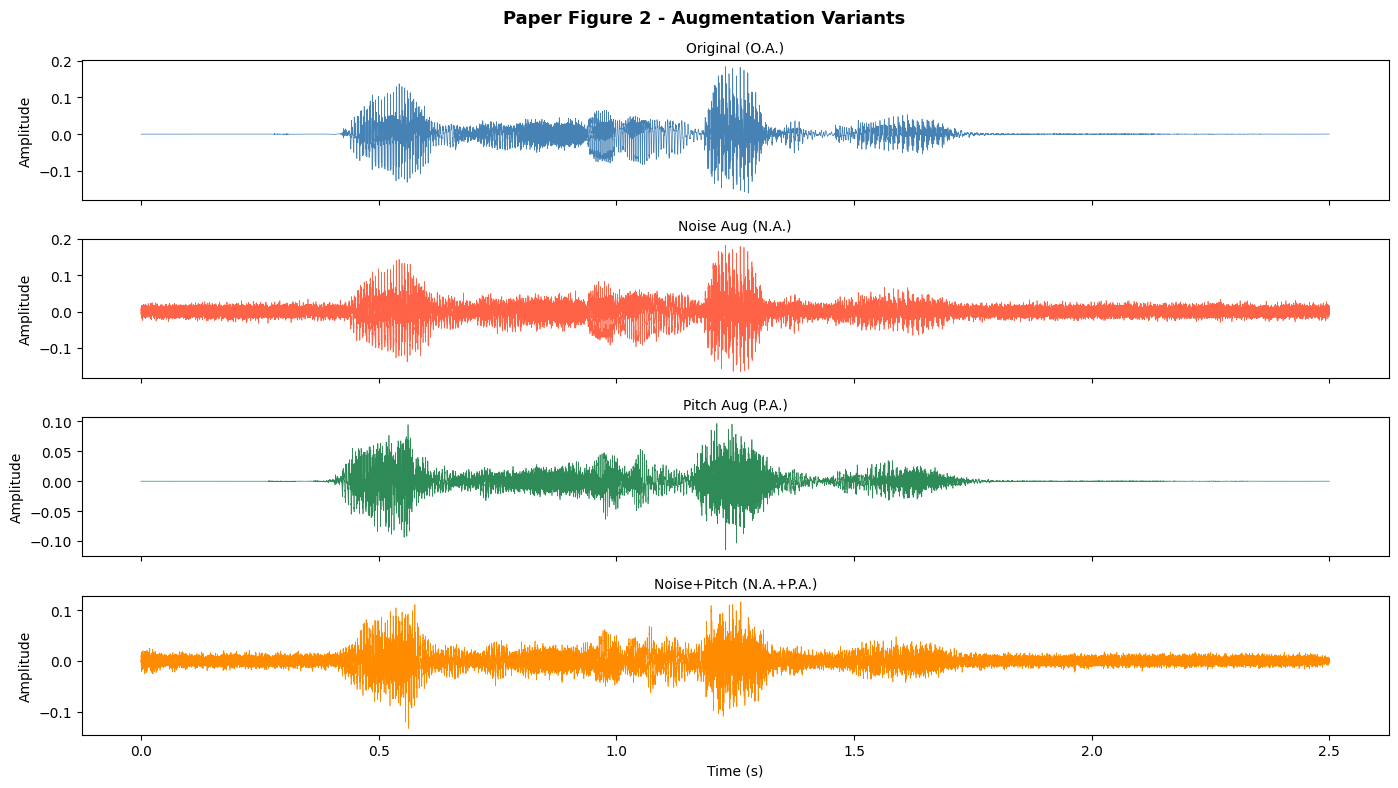

In [53]:
# Visualize the 4 augmentation variants
sr   = 22050
y_ex = load_and_pad(samples[0][0])
augs = [
    ('Original (O.A.)',          y_ex),
    ('Noise Aug (N.A.)',         augment_noise(y_ex)),
    ('Pitch Aug (P.A.)',         augment_pitch(y_ex, sr=sr)),
    ('Noise+Pitch (N.A.+P.A.)', augment_pitch(augment_noise(y_ex), sr=sr)),
]
fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']
for ax, (title, sig), color in zip(axes, augs, colors):
    t = np.linspace(0, len(sig)/sr, len(sig))
    ax.plot(t, sig, lw=0.5, color=color)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Amplitude')
axes[-1].set_xlabel('Time (s)')
plt.suptitle('Paper Figure 2 - Augmentation Variants', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
from tqdm import tqdm
from utils.config import EMOTION_TO_IDX
from data.dataset_loader import train_val_test_split
from sklearn.preprocessing import StandardScaler

def build_paper_dataset(sample_list, augment=True, sr=22050, verbose=True):
    X_list, y_list = [], []
    it = tqdm(sample_list, desc='Extracting') if verbose else sample_list
    for path, label in it:
        if label not in EMOTION_TO_IDX:
            continue
        idx = EMOTION_TO_IDX[label]
        try:
            if augment:
                for feat in extract_all_augmentations(path, sr):
                    X_list.append(feat)
                    y_list.append(idx)
            else:
                y_audio = load_and_pad(path, sr=sr)
                X_list.append(extract_paper_features(y_audio, sr))
                y_list.append(idx)
        except Exception as e:
            if verbose: print(f'  [skip] {path}: {e}')
    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int64)
    print(f'  Shape: {X.shape}')
    return X, y


train_s, val_s, test_s = train_val_test_split(samples, val_split=0.1, test_split=0.1)

print('Building train set (4x augmentation)...')
X_train, y_train = build_paper_dataset(train_s, augment=True)
print('Building val set...')
X_val,   y_val   = build_paper_dataset(val_s,   augment=False)
print('Building test set...')
X_test,  y_test  = build_paper_dataset(test_s,  augment=False)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)
print(f'Normalized - train mean={X_train.mean():.4f}, std={X_train.std():.4f}')

num_classes = len(set(y_train.tolist()))
print(f'Classes: {num_classes}')

Split → train: 1152, val: 144, test: 144
Building train set (4x augmentation)...


Extracting: 100%|██████████| 1152/1152 [19:19<00:00,  1.01s/it]


  Shape: (4608, 3800)
Building val set...


Extracting: 100%|██████████| 144/144 [01:40<00:00,  1.43it/s]


  Shape: (144, 3800)
Building test set...


Extracting: 100%|██████████| 144/144 [01:40<00:00,  1.43it/s]


  Shape: (144, 3800)
Normalized - train mean=0.0000, std=1.0000
Classes: 7


## 6. Model Selection & Training

Set `MODELS_TO_TRAIN` to any combination of:
- `'svm'` — Support Vector Machine (baseline, no GPU needed)
- `'lr'` — Logistic Regression (baseline, no GPU needed)
- `'paper_cnn_bilstm'` — Paper-exact CNN + Bi-LSTM (GPU recommended)
- `'cnn'` — CNN on spectrograms
- `'lstm'` — Bidirectional LSTM
- `'cnn_lstm'` — Hybrid CNN + LSTM

In [14]:
# ── Choose which models to train ──────────────────────────────
MODELS_TO_TRAIN = [
    'svm',
    'paper_cnn_bilstm'
]
# Add/remove from the list above. All results are saved and compared at the end.

# ── Shared training settings ──────────────────────────────────
EPOCHS       = 100
EARLY_STOP   = 900    # increased from paper's 5 — needed for small datasets
BATCH_SIZE   = 64

print('Will train:', MODELS_TO_TRAIN)

Will train: ['svm', 'paper_cnn_bilstm']


In [15]:
# ── Shared imports & helpers ───────────────────────────────────
import torch
import torch.nn as nn
import time
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from evaluation.metrics import compute_metrics, print_report
from utils.config import EMOTIONS
from utils.visualization import plot_confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Store results from all trained models for comparison
all_results = {}


class FlatFeatureDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_dl = DataLoader(FlatFeatureDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_dl   = DataLoader(FlatFeatureDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_dl  = DataLoader(FlatFeatureDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


def train_deep_model(model, name, epochs=EPOCHS, early_stop=EARLY_STOP):
    """Generic training loop for any deep model."""
    optimizer     = Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler     = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-5)
    criterion     = nn.CrossEntropyLoss()
    ckpt_path     = f'{CHECKPOINT_DIR}/{name}_best.pt'
    best_val_acc  = 0.0
    patience_left = early_stop
    history       = {'train_loss': [], 'train_acc': [], 'val_acc': []}

    print(f'\nTraining {name} for up to {epochs} epochs (early stop patience={early_stop})\n')

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        model.train()
        train_loss = train_correct = train_total = 0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out  = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            train_loss    += loss.item() * len(yb)
            train_correct += (out.argmax(1) == yb).sum().item()
            train_total   += len(yb)

        model.eval()
        val_correct = val_total = 0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                val_correct += (model(xb).argmax(1) == yb).sum().item()
                val_total   += len(yb)

        train_acc = train_correct / train_total
        val_acc   = val_correct   / val_total
        lr_now    = optimizer.param_groups[0]['lr']
        scheduler.step(val_acc)

        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch:3d}/{epochs}  loss={train_loss/train_total:.4f}  '
              f'train={train_acc:.4f}  val={val_acc:.4f}  '
              f'lr={lr_now:.2e}  gap={train_acc-val_acc:.4f}  {time.time()-t0:.1f}s')

        if val_acc > best_val_acc:
            best_val_acc  = val_acc
            patience_left = early_stop
            torch.save({
                'epoch': epoch, 'model_state': model.state_dict(),
                'val_acc': val_acc, 'scaler': scaler,
                'num_classes': num_classes, 'input_features': X_train.shape[1],
            }, ckpt_path)
            print(f'  ✓ Best val={val_acc:.4f} saved')
        else:
            patience_left -= 1
            print(f'  patience: {patience_left}/{early_stop}')
            if patience_left == 0:
                print(f'  Early stopping at epoch {epoch}')
                break

    # Plot training curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history['train_loss'], color='steelblue')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].grid(alpha=0.3)
    axes[1].plot([a*100 for a in history['train_acc']], label='Train', color='steelblue')
    axes[1].plot([a*100 for a in history['val_acc']],   label='Val',   color='tomato', linestyle='--')
    axes[1].set_title('Accuracy (%)')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.suptitle(f'{name} Training History', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Evaluate on test set
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, yb in test_dl:
            preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
            labels.extend(yb.numpy())

    preds  = np.array(preds)
    labels = np.array(labels)
    print_report(labels, preds, EMOTIONS, title=f'{name} - Test Results')

    m = compute_metrics(labels, preds)
    fig = plot_confusion_matrix(m['confusion_matrix'], labels=m['present_labels'],
                                 title=f'{name} Confusion Matrix')
    plt.show()
    return m, preds, labels

print('Helpers ready')

Device: cuda
Helpers ready


In [19]:
# ── Train SVM ─────────────────────────────────────────────────
if 'svm' in MODELS_TO_TRAIN:
    from models.baseline import train_baseline, save_baseline
    print('\n=== SVM ===')
    svm = train_baseline('svm', X_train, y_train, tune=False, cv=5)
    save_baseline(svm, f'{CHECKPOINT_DIR}/svm_baseline.pkl')
    svm_preds = svm.predict(X_test)
    print_report(y_test, svm_preds, EMOTIONS, title='SVM - Test Results')
    m = compute_metrics(y_test, svm_preds)
    fig = plot_confusion_matrix(m['confusion_matrix'], labels=m['present_labels'], title='SVM Confusion Matrix')
    plt.show()
    all_results['SVM'] = m
else:
    print('Skipping SVM')


=== SVM ===
Saved baseline model → /content/drive/MyDrive/speech_emotion_checkpoints/svm_baseline.pkl

  SVM - Test Results
  Accuracy:            0.7292
  F1 (macro):          0.7072
  F1 (weighted):       0.7270
  Precision (macro):   0.7131
  Recall (macro):      0.7095

  Per-class F1:
    angry       : 0.750  ███████████████
    disgust     : 0.750  ███████████████
    fear        : 0.645  ████████████
    happy       : 0.632  ████████████
    neutral     : 0.842  ████████████████
    sad         : 0.600  ████████████
    surprised   : 0.732  ██████████████

  Sklearn Classification Report:

              precision    recall  f1-score   support

       angry       0.71      0.79      0.75        19
     disgust       0.75      0.75      0.75        16
        fear       0.59      0.71      0.65        14
       happy       0.71      0.57      0.63        21
     neutral       0.80      0.89      0.84        36
         sad       0.60      0.60      0.60        15
   surprised    

In [ ]:
# ── Train Logistic Regression ─────────────────────────────────
if 'lr' in MODELS_TO_TRAIN:
    from models.baseline import train_baseline, save_baseline
    print('\n=== Logistic Regression ===')
    lr_model = train_baseline('lr', X_train, y_train, tune=True, cv=5)
    save_baseline(lr_model, f'{CHECKPOINT_DIR}/lr_baseline.pkl')
    lr_preds = lr_model.predict(X_test)
    print_report(y_test, lr_preds, EMOTIONS, title='LR - Test Results')
    m = compute_metrics(y_test, lr_preds)
    fig = plot_confusion_matrix(m['confusion_matrix'], labels=m['present_labels'], title='LR Confusion Matrix')
    plt.show()
    all_results['LogisticRegression'] = m
else:
    print('Skipping Logistic Regression')

In [64]:
%%writefile /content/drive/MyDrive/speech_emotion/models/paper_cnn_bilstm.py

"""
models/paper_cnn_bilstm.py

Exact replication of Table 2 from:
  "Speech emotion recognition with light weight deep neural ensemble model
   using hand crafted features" (Nature, 2025)

Architecture:
  Block 1: Conv1D(128, k=5) -> BN -> ReLU -> MaxPool
  Block 2: Conv1D(128, k=5) -> BN -> ReLU -> MaxPool -> Dropout(0.2)
  Block 3: Conv1D(64,  k=5) -> BN -> ReLU -> MaxPool
  Block 4: Conv1D(64,  k=3) -> BN -> ReLU -> MaxPool -> Dropout(0.2)
  Bi-LSTM: hidden=64, bidirectional -> output 128
  Block 5: Conv1D(32,  k=3) -> BN -> ReLU -> MaxPool -> Dropout(0.2)
  Flatten -> Dense(128) -> BN -> ReLU -> Dense(num_classes)

Input:  (batch, feature_dim)  flat 1D feature vector
Output: (batch, num_classes)  logits
"""

import torch
import torch.nn as nn


class PaperCNNBiLSTM(nn.Module):

    def __init__(self, input_features: int, num_classes: int = 7):
        super().__init__()

        # Block 1 — kernel 5, no dropout
        self.block1 = nn.Sequential(
            nn.Conv1d(1, 128, kernel_size=5, padding="same"),
            nn.BatchNorm1d(128),
            #nn.ReLU(),
            nn.MaxPool1d(2),
        )
        # Block 2 — kernel 5, dropout
        self.block2 = nn.Sequential(
            nn.Conv1d(128, 128, kernel_size=5, padding="same"),
            nn.BatchNorm1d(128),
            #nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),
        )
        # Block 3 — kernel 5, no dropout
        self.block3 = nn.Sequential(
            nn.Conv1d(128, 64, kernel_size=5, padding="same"),
            nn.BatchNorm1d(64),
            #nn.ReLU(),
            nn.MaxPool1d(2),
        )
        # Block 4 — kernel 3, dropout
        self.block4 = nn.Sequential(
            nn.Conv1d(64, 64, kernel_size=3, padding="same"),
            nn.BatchNorm1d(64),
            #nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),
        )

        # Bi-LSTM inserted between block 4 and block 5
        # input_size=64 (from block4 channels), hidden=64, bidirectional -> 128 out
        self.bilstm = nn.LSTM(
            input_size=64,
            hidden_size=64,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )

        # Block 5 — kernel 3, dropout
        self.block5 = nn.Sequential(
            nn.Conv1d(128, 32, kernel_size=3, padding="same"),
            nn.BatchNorm1d(32),
            #nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),
        )

        # Compute flattened size dynamically so any input_features works
        with torch.no_grad():
            d = torch.zeros(1, 1, input_features)
            d = self.block1(d)
            d = self.block2(d)
            d = self.block3(d)
            d = self.block4(d)
            d, _ = self.bilstm(d.permute(0, 2, 1))
            d = self.block5(d.permute(0, 2, 1))
            flat_size = d.flatten(1).shape[1]

        print(f"  PaperCNNBiLSTM: input={input_features}  flat={flat_size}  classes={num_classes}")

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, feature_dim)
        Returns:
            logits: (B, num_classes)
        """
        x = x.unsqueeze(1)                      # (B, feat) -> (B, 1, feat)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = x.permute(0, 2, 1)                  # -> (B, seq, 64)
        x, _ = self.bilstm(x)                   # -> (B, seq, 128)
        x = x.permute(0, 2, 1)                  # -> (B, 128, seq)
        x = self.block5(x)
        return self.head(x)

    def predict_proba(self, x: torch.Tensor) -> torch.Tensor:
        return torch.softmax(self.forward(x), dim=-1)


def build_paper_cnn_bilstm(input_features: int, num_classes: int = 7) -> PaperCNNBiLSTM:
    return PaperCNNBiLSTM(input_features=input_features, num_classes=num_classes)


if __name__ == "__main__":
    model = build_paper_cnn_bilstm(input_features=X_train.shape[1], num_classes=7)
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
    dummy = torch.randn(4, 3672)

Overwriting /content/drive/MyDrive/speech_emotion/models/paper_cnn_bilstm.py


In [67]:
# Force reload after editing the file
import importlib
import models.paper_cnn_bilstm as m
importlib.reload(m)
from models.paper_cnn_bilstm import PaperCNNBiLSTM

model = PaperCNNBiLSTM(input_features=3672, num_classes=7).to(device)
print(sum(p.numel() for p in model.parameters()))

  PaperCNNBiLSTM: input=3672  flat=3648  classes=7
684135


In [69]:
# Check your actual feature dim first
print(f'X_train shape: {X_train.shape}')  # (N, feature_dim)
print(f'feature_dim: {X_train.shape[1]}')

# Then rebuild the model with the correct input size
from models.paper_cnn_bilstm import PaperCNNBiLSTM
import importlib
import models.paper_cnn_bilstm as m_module
importlib.reload(m_module)
from models.paper_cnn_bilstm import PaperCNNBiLSTM

model = PaperCNNBiLSTM(
    input_features=X_train.shape[1],  # use actual dim from data
    num_classes=num_classes
).to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

X_train shape: (6324, 3800)
feature_dim: 3800
  PaperCNNBiLSTM: input=3800  flat=3776  classes=7
Parameters: 700,519



=== Paper CNN-BiLSTM ===
  PaperCNNBiLSTM: input=3800  flat=3776  classes=7
Parameters: 700,519

Training paper_cnn_bilstm for up to 100 epochs (early stop patience=900)

Epoch   1/100  loss=1.2683  train=0.5357  val=0.5381  lr=1.00e-03  gap=-0.0023  6.5s
  ✓ Best val=0.5381 saved
Epoch   2/100  loss=0.8442  train=0.6962  val=0.6751  lr=1.00e-03  gap=0.0211  6.4s
  ✓ Best val=0.6751 saved
Epoch   3/100  loss=0.5981  train=0.7955  val=0.6294  lr=1.00e-03  gap=0.1661  6.3s
  patience: 899/900
Epoch   4/100  loss=0.4400  train=0.8539  val=0.7056  lr=1.00e-03  gap=0.1483  6.3s
  ✓ Best val=0.7056 saved
Epoch   5/100  loss=0.3180  train=0.8985  val=0.7563  lr=1.00e-03  gap=0.1421  6.1s
  ✓ Best val=0.7563 saved
Epoch   6/100  loss=0.2369  train=0.9255  val=0.7107  lr=1.00e-03  gap=0.2149  6.1s
  patience: 899/900
Epoch   7/100  loss=0.1734  train=0.9500  val=0.7614  lr=1.00e-03  gap=0.1886  5.9s
  ✓ Best val=0.7614 saved
Epoch   8/100  loss=0.1367  train=0.9594  val=0.7513  lr=1.00e-03  ga

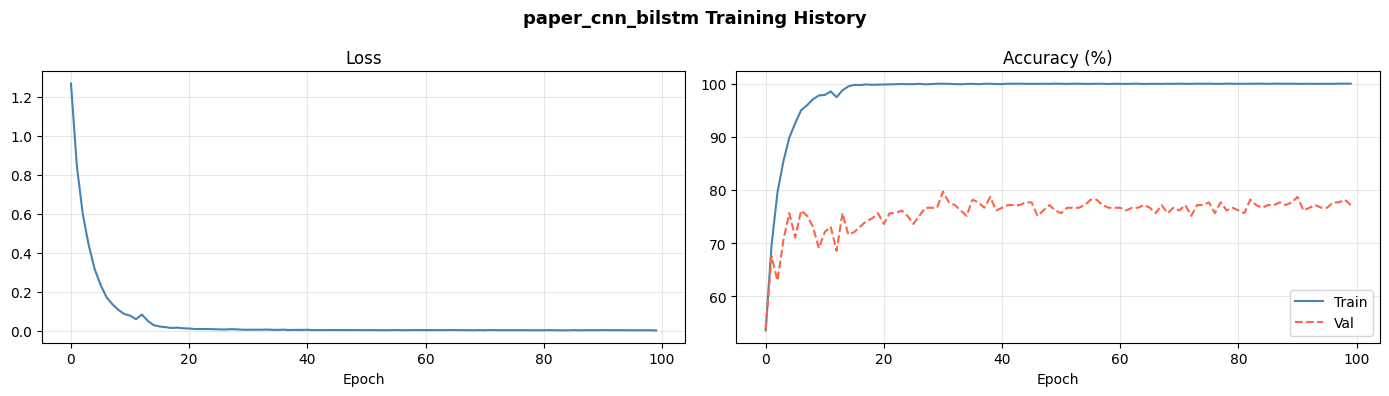


  paper_cnn_bilstm - Test Results
  Accuracy:            0.7513
  F1 (macro):          0.7323
  F1 (weighted):       0.7447
  Precision (macro):   0.7418
  Recall (macro):      0.7318

  Per-class F1:
    angry       : 0.833  ████████████████
    disgust     : 0.829  ████████████████
    fear        : 0.612  ████████████
    happy       : 0.500  ██████████
    neutral     : 0.822  ████████████████
    sad         : 0.678  █████████████
    surprised   : 0.851  █████████████████

  Sklearn Classification Report:

              precision    recall  f1-score   support

       angry       0.79      0.88      0.83        34
     disgust       0.85      0.81      0.83        21
        fear       0.60      0.62      0.61        24
       happy       0.64      0.41      0.50        22
     neutral       0.79      0.86      0.82        43
         sad       0.69      0.67      0.68        30
   surprised       0.83      0.87      0.85        23

    accuracy                           0.75    

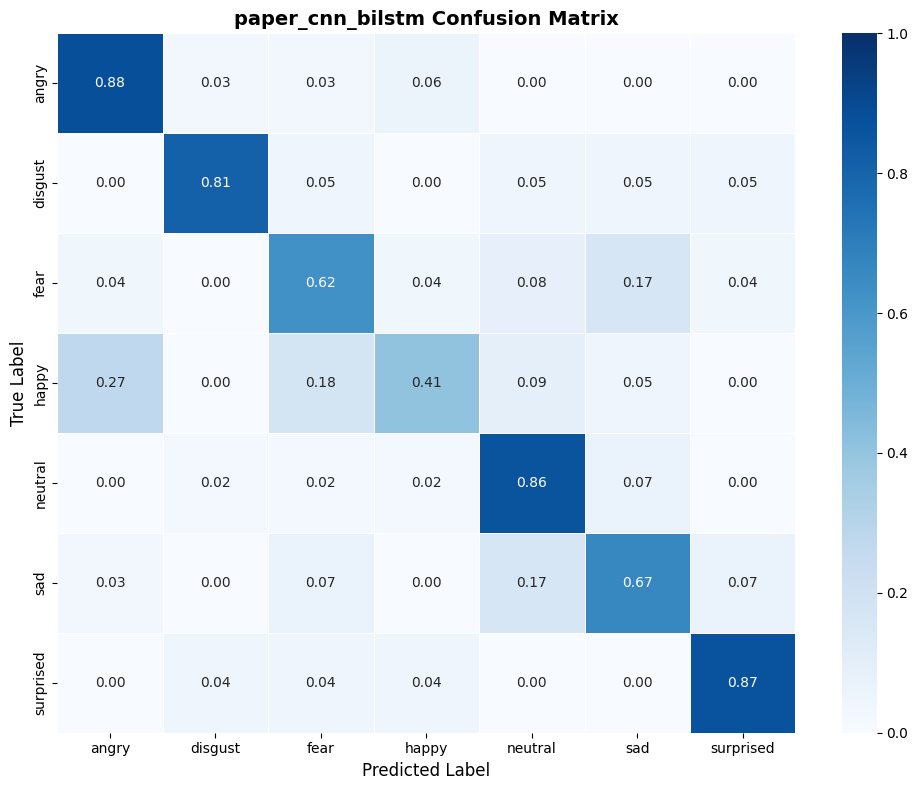

In [70]:
# ── Train Paper CNN-BiLSTM ────────────────────────────────────
if 'paper_cnn_bilstm' in MODELS_TO_TRAIN:
    from models.paper_cnn_bilstm import PaperCNNBiLSTM
    print('\n=== Paper CNN-BiLSTM ===')
    model = PaperCNNBiLSTM(input_features=X_train.shape[1], num_classes=num_classes).to(device)
    print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
    m, cnn_bilstm_preds, cnn_bilstm_labels = train_deep_model(model, 'paper_cnn_bilstm')
    all_results['CNN-BiLSTM'] = m
else:
    print('Skipping Paper CNN-BiLSTM')


=== CNN (spectrogram, 4x aug) ===
Train: 4608  Val: 144  Test: 144
Parameters: 1,251,305
Epoch   1/100  loss=1.9461  train=0.1949  val=0.2778  gap=-0.0829  214.2s
  Best val=0.2778 saved
Epoch   2/100  loss=1.8188  train=0.2498  val=0.3333  gap=-0.0836  216.5s
  Best val=0.3333 saved
Epoch   3/100  loss=1.7554  train=0.2980  val=0.3333  gap=-0.0354  209.2s
  patience: 899/900
Epoch   4/100  loss=1.6730  train=0.3605  val=0.3333  gap=0.0271  207.1s
  patience: 898/900
Epoch   5/100  loss=1.6018  train=0.3861  val=0.3889  gap=-0.0028  210.7s
  Best val=0.3889 saved
Epoch   6/100  loss=1.5342  train=0.4182  val=0.4236  gap=-0.0054  207.6s
  Best val=0.4236 saved
Epoch   7/100  loss=1.4611  train=0.4503  val=0.4306  gap=0.0197  211.4s
  Best val=0.4306 saved
Epoch   8/100  loss=1.4161  train=0.4620  val=0.4306  gap=0.0315  209.5s
  patience: 899/900
Epoch   9/100  loss=1.3696  train=0.4846  val=0.4236  gap=0.0610  213.1s
  patience: 898/900
Epoch  10/100  loss=1.3133  train=0.5037  val=0.

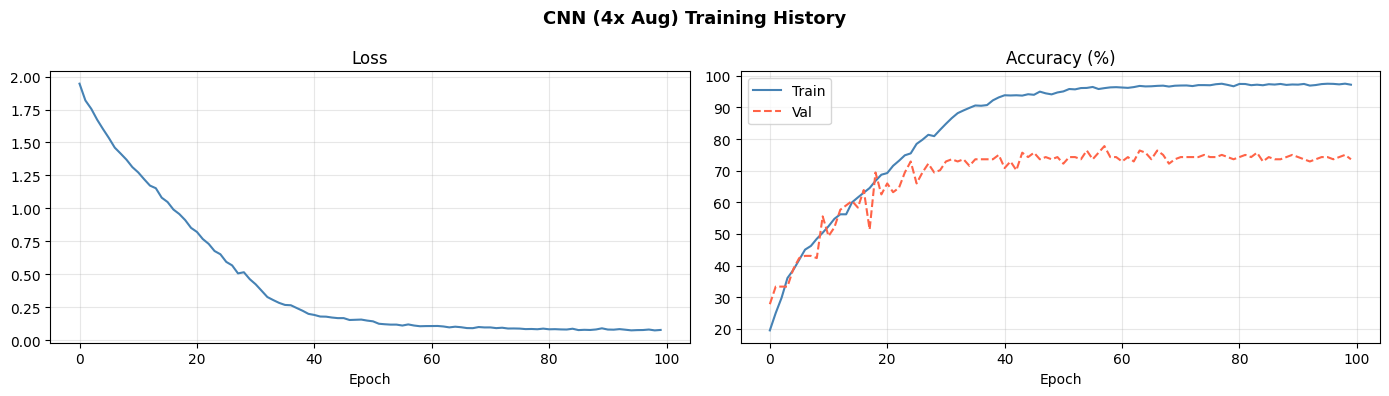


  CNN (4x Aug) - Test Results
  Accuracy:            0.6875
  F1 (macro):          0.6642
  F1 (weighted):       0.6916
  Precision (macro):   0.6625
  Recall (macro):      0.6683

  Per-class F1:
    angry       : 0.632  ████████████
    disgust     : 0.647  ████████████
    fear        : 0.643  ████████████
    happy       : 0.558  ███████████
    neutral     : 0.866  █████████████████
    sad         : 0.581  ███████████
    surprised   : 0.723  ██████████████

  Sklearn Classification Report:

              precision    recall  f1-score   support

       angry       0.63      0.63      0.63        19
     disgust       0.61      0.69      0.65        16
        fear       0.64      0.64      0.64        14
       happy       0.55      0.57      0.56        21
     neutral       0.94      0.81      0.87        36
         sad       0.56      0.60      0.58        15
   surprised       0.71      0.74      0.72        23

    accuracy                           0.69       144
   macro

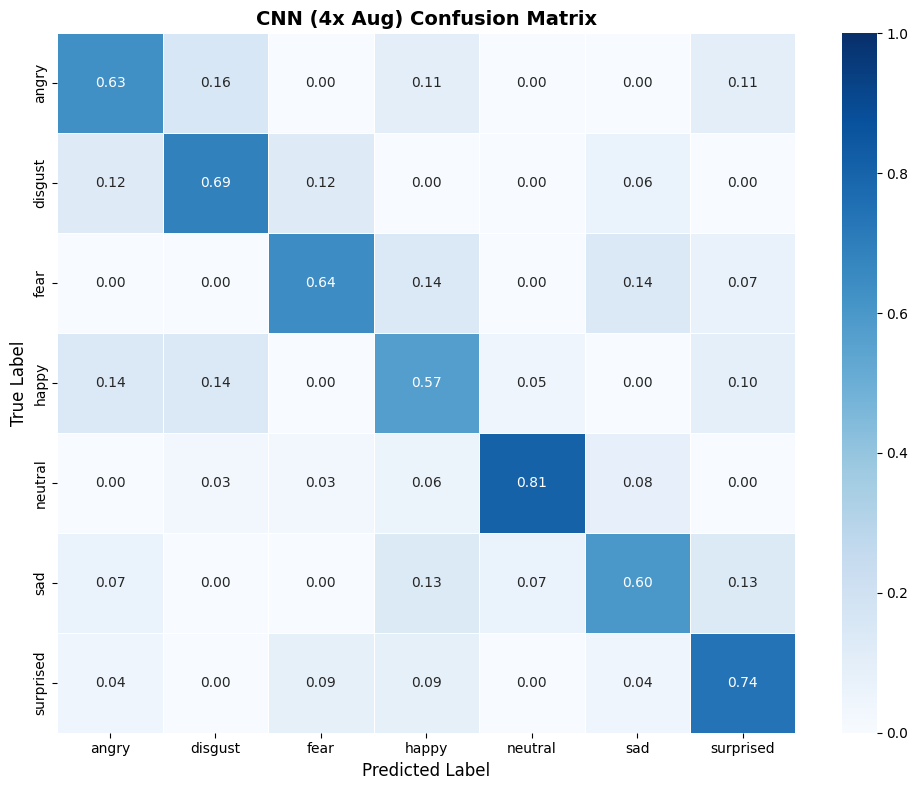

In [28]:
if "cnn" in MODELS_TO_TRAIN:
    import librosa
    from torch.utils.data import Dataset, DataLoader
    from models.cnn import build_cnn
    from utils.config import CNN_CFG, EMOTION_TO_IDX, EMOTIONS
    from collections import Counter

    class AugmentedSpectrogramDataset(Dataset):
        def __init__(self, sample_list, augment=True, sr=22050, duration=2.5, offset=0.6):
            self.sr = sr
            self.augment = augment
            self.duration = duration
            self.offset = offset
            self.items = [(p, EMOTION_TO_IDX[l]) for p, l in sample_list if l in EMOTION_TO_IDX]

        def _load(self, path):
            y, _ = librosa.load(path, sr=self.sr, duration=self.duration,
                                offset=self.offset, mono=True)
            target = int(self.sr * self.duration)
            if len(y) < target:
                y = np.pad(y, (0, target - len(y)))
            return y[:target]

        def _noise(self, y, amp=0.035):
            noise = np.random.normal(0, 1, len(y))
            return y + amp * noise / (np.max(np.abs(noise)) + 1e-8)

        def _pitch(self, y, factor=0.7):
            return librosa.effects.pitch_shift(y, sr=self.sr, n_steps=factor)

        def _spec(self, y):
            S = librosa.feature.melspectrogram(y=y, sr=self.sr, n_mels=128,
                                               n_fft=2048, hop_length=512)
            S = librosa.power_to_db(S, ref=np.max)
            return ((S - S.mean()) / (S.std() + 1e-8)).astype(np.float32)

        def __len__(self):
            return len(self.items) * (4 if self.augment else 1)

        def __getitem__(self, idx):
            file_idx = idx // 4 if self.augment else idx
            aug_type = idx % 4 if self.augment else 3
            path, label = self.items[file_idx]
            y = self._load(path)
            if aug_type == 0:
                y = self._noise(y)
            elif aug_type == 1:
                y = self._pitch(y)
            elif aug_type == 2:
                y = self._pitch(self._noise(y))
            # aug_type == 3: original, no change
            spec = self._spec(y)
            return torch.tensor(spec).unsqueeze(0), torch.tensor(label, dtype=torch.long)

    cnn_train_dl = DataLoader(AugmentedSpectrogramDataset(train_s, augment=True),
                              batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    cnn_val_dl   = DataLoader(AugmentedSpectrogramDataset(val_s,   augment=False),
                              batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    cnn_test_dl  = DataLoader(AugmentedSpectrogramDataset(test_s,  augment=False),
                              batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    print(f"\n=== CNN (spectrogram, 4x aug) ===")
    print(f"Train: {len(cnn_train_dl.dataset)}  Val: {len(cnn_val_dl.dataset)}  Test: {len(cnn_test_dl.dataset)}")

    # The num_classes variable was previously derived from the unique classes in y_train.
    # However, for CrossEntropyLoss, the weight tensor should cover all possible classes
    # that the model can predict, as defined by the EMOTIONS list.
    # We'll explicitly set num_classes to the total number of emotions based on the user's change.
    num_classes_for_loss = len(EMOTIONS)

    # Since CNN_CFG is an object (not a dictionary), we directly update its attribute
    # to ensure the model is built with the correct number of output classes.
    CNN_CFG.num_classes = num_classes_for_loss

    cnn_model = build_cnn(CNN_CFG).to(device)
    print(f"Parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")

    # Weighted loss for class imbalance
    counts  = Counter(y_train.tolist())
    total   = sum(counts.values())
    # Initialize weights for all classes (e.g., 7 if EMOTIONS has 7 elements)
    weights = torch.zeros(num_classes_for_loss)
    for idx, count in counts.items():
        weights[idx] = total / (num_classes_for_loss * count)
    cnn_criterion = nn.CrossEntropyLoss(weight=weights.to(device))

    cnn_optimizer = Adam(cnn_model.parameters(), lr=3e-4, weight_decay=1e-3)
    cnn_scheduler = ReduceLROnPlateau(cnn_optimizer, mode="max", factor=0.5, patience=5, min_lr=1e-5)
    best_val_acc  = 0.0
    patience_left = EARLY_STOP
    ckpt_path     = f"{CHECKPOINT_DIR}/cnn_augmented_best.pt"
    history       = {"train_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        cnn_model.train()
        train_loss = train_correct = train_total = 0
        for xb, yb in cnn_train_dl:
            xb, yb = xb.to(device), yb.to(device)
            cnn_optimizer.zero_grad()
            out  = cnn_model(xb)
            loss = cnn_criterion(out, yb)
            loss.backward()
            cnn_optimizer.step()
            train_loss    += loss.item() * len(yb)
            train_correct += (out.argmax(1) == yb).sum().item()
            train_total   += len(yb)

        cnn_model.eval()
        val_correct = val_total = 0
        with torch.no_grad():
            for xb, yb in cnn_val_dl:
                xb, yb = xb.to(device), yb.to(device)
                val_correct += (cnn_model(xb).argmax(1) == yb).sum().item()
                val_total   += len(yb)

        train_acc = train_correct / train_total
        val_acc   = val_correct   / val_total
        cnn_scheduler.step(val_acc)
        history["train_loss"].append(train_loss / train_total)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:3d}/{EPOCHS}  loss={train_loss/train_total:.4f}  "
              f"train={train_acc:.4f}  val={val_acc:.4f}  "
              f"gap={train_acc-val_acc:.4f}  {time.time()-t0:.1f}s")

        if val_acc > best_val_acc:
            best_val_acc  = val_acc
            patience_left = EARLY_STOP
            torch.save({"model_state": cnn_model.state_dict(), "val_acc": val_acc}, ckpt_path)
            print(f"  Best val={val_acc:.4f} saved")
        else:
            patience_left -= 1
            print(f"  patience: {patience_left}/{EARLY_STOP}")
            if patience_left == 0:
                print(f"  Early stopping at epoch {epoch}")
                break

    # Training curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history["train_loss"], color="steelblue")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].grid(alpha=0.3)
    axes[1].plot([a*100 for a in history["train_acc"]], label="Train", color="steelblue")
    axes[1].plot([a*100 for a in history["val_acc"]],   label="Val",   color="tomato", linestyle="--")
    axes[1].set_title("Accuracy (%)"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.suptitle("CNN (4x Aug) Training History", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

    # Test evaluation
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    cnn_model.load_state_dict(ckpt["model_state"])
    cnn_model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in cnn_test_dl:
            all_preds.extend(cnn_model(xb.to(device)).argmax(1).cpu().numpy())
            all_labels.extend(yb.numpy())
    all_labels, all_preds = np.array(all_labels), np.array(all_preds)
    print_report(all_labels, all_preds, EMOTIONS, title="CNN (4x Aug) - Test Results")
    m = compute_metrics(all_labels, all_preds)
    all_results["CNN (4x Aug)"] = m
    fig = plot_confusion_matrix(m["confusion_matrix"], labels=m["present_labels"],
                                title="CNN (4x Aug) Confusion Matrix")
    plt.show()
else:
    print("Skipping CNN")

In [ ]:
# ── Train CNN+LSTM (spectrogram-based) ────────────────────────
if 'cnn_lstm' in MODELS_TO_TRAIN:
    from train import build_model, train_epoch, eval_epoch
    from utils.config import AUDIO_CFG
    from data.dataset_loader import make_dataloaders
    print('\n=== CNN+LSTM (spectrogram) ===')
    cnn_lstm_model = build_model('cnn_lstm', AUDIO_CFG).to(device)
    cnn_lstm_train_dl, cnn_lstm_val_dl, cnn_lstm_test_dl = make_dataloaders(
        train_s, val_s, test_s, feature_type='spectrogram', batch_size=BATCH_SIZE, num_workers=2
    )
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = Adam(cnn_lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-5)
    best_val_f1   = 0.0
    patience_left = EARLY_STOP
    ckpt_path     = f'{CHECKPOINT_DIR}/cnn_lstm_best.pt'
    for epoch in range(1, EPOCHS + 1):
        train_m = train_epoch(cnn_lstm_model, cnn_lstm_train_dl, optimizer, criterion, device)
        val_m   = eval_epoch(cnn_lstm_model, cnn_lstm_val_dl, criterion, device)
        val_f1  = compute_metrics(val_m['labels'], val_m['preds'])['f1_weighted']
        scheduler.step(val_f1)
        print(f'Epoch {epoch:3d}  train_acc={train_m["acc"]:.4f}  val_acc={val_m["acc"]:.4f}  val_f1={val_f1:.4f}')
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_left = EARLY_STOP
            torch.save({'model_state': cnn_lstm_model.state_dict()}, ckpt_path)
            print('  ✓ Saved')
        else:
            patience_left -= 1
            if patience_left == 0:
                print(f'  Early stopping at epoch {epoch}')
                break
    cnn_lstm_model.load_state_dict(torch.load(ckpt_path, weights_only=False)['model_state'])
    test_m = eval_epoch(cnn_lstm_model, cnn_lstm_test_dl, criterion, device)
    print_report(test_m['labels'], test_m['preds'], EMOTIONS, title='CNN+LSTM - Test Results')
    all_results['CNN+LSTM'] = compute_metrics(test_m['labels'], test_m['preds'])
else:
    print('Skipping CNN+LSTM')

In [8]:
# ── Reference CNN (adapted from CNN_Speech_Emotion_Recognition.ipynb) ─────────
# Uses mean-aggregated MFCC(40) + Chroma(12) + Mel(128) = 180-dim features
# with our 4x augmentation strategy (NA, PA, NA+PA, OA)

import torch
import torch.nn as nn
import numpy as np
import librosa
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from collections import Counter
import time

# ── Feature extraction (matches reference notebook exactly) ───────────────────
def extract_180_features(y, sr=22050):
    """MFCC(40) + Chroma(12) + Mel(128) mean-aggregated = 180-dim vector."""
    stft   = np.abs(librosa.stft(y))
    mfcc   = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    chroma = np.mean(librosa.feature.chroma_stft(S=stft, sr=sr).T, axis=0)
    mel    = np.mean(librosa.feature.melspectrogram(y=y, sr=sr).T, axis=0)
    feat   = np.hstack([mfcc, chroma, mel])
    return np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


# ── Build dataset with our 4x augmentation ────────────────────────────────────
def build_180_dataset(sample_list, augment=True, sr=22050, verbose=True):
    """
    Same 4x augmentation as paper (NA, PA, NA+PA, OA) but
    extracts 180-dim mean features instead of 3672-dim flat features.
    """
    from tqdm import tqdm
    from utils.config import EMOTION_TO_IDX

    X_list, y_list = [], []
    it = tqdm(sample_list, desc='Extracting 180-dim') if verbose else sample_list

    for path, label in it:
        if label not in EMOTION_TO_IDX:
            continue
        idx = EMOTION_TO_IDX[label]
        try:
            y_audio = load_and_pad(path, sr=sr)  # your existing function
            if augment:
                y_na   = augment_noise(y_audio)
                y_pa   = augment_pitch(y_audio, sr=sr)
                y_napa = augment_pitch(augment_noise(y_audio), sr=sr)
                for y_aug in [y_na, y_pa, y_napa, y_audio]:
                    X_list.append(extract_180_features(y_aug, sr))
                    y_list.append(idx)
            else:
                X_list.append(extract_180_features(y_audio, sr))
                y_list.append(idx)
        except Exception as e:
            if verbose: print(f'  [skip] {path}: {e}')

    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int64)
    print(f'  Shape: {X.shape}')
    return X, y


# ── Build datasets ─────────────────────────────────────────────────────────────
print('Building 180-dim datasets...')
X_train_180, y_train_180 = build_180_dataset(train_s, augment=True)
X_val_180,   y_val_180   = build_180_dataset(val_s,   augment=False)
X_test_180,  y_test_180  = build_180_dataset(test_s,  augment=False)

# StandardScaler
from sklearn.preprocessing import StandardScaler
scaler_180  = StandardScaler()
X_train_180 = scaler_180.fit_transform(X_train_180)
X_val_180   = scaler_180.transform(X_val_180)
X_test_180  = scaler_180.transform(X_test_180)
print(f'Normalized. Feature dim: {X_train_180.shape[1]}')

Building 180-dim datasets...


Extracting 180-dim: 100%|██████████| 1152/1152 [03:55<00:00,  4.89it/s]


  Shape: (4608, 180)


Extracting 180-dim: 100%|██████████| 144/144 [00:07<00:00, 18.70it/s]


  Shape: (144, 180)


Extracting 180-dim: 100%|██████████| 144/144 [00:04<00:00, 31.15it/s]

  Shape: (144, 180)
Normalized. Feature dim: 180


In [9]:
print(f'X_train_180 shape: {X_train_180.shape}')    # should be (N, 180)
print(f'Mean: {X_train_180.mean():.4f}')             # should be ~0 after scaling
print(f'Std:  {X_train_180.std():.4f}')              # should be ~1 after scaling
print(f'Any NaN: {np.isnan(X_train_180).any()}')     # should be False
print(f'Any Inf: {np.isinf(X_train_180).any()}')     # should be False

X_train_180 shape: (4608, 180)
Mean: 0.0000
Std:  1.0000
Any NaN: False
Any Inf: False


In [11]:
class FlatFeatureDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

In [16]:
# ── Reference CNN model (PyTorch port of the Keras architecture) ───────────────
class ReferenceCNN(nn.Module):
    """
    PyTorch port of CNN_Speech_Emotion_Recognition.ipynb.

    Architecture:
        Conv1D(256, k=5) -> ReLU
        Conv1D(128, k=5) -> ReLU -> Dropout(0.1) -> MaxPool(8)
        Conv1D(128, k=5) -> ReLU
        Conv1D(128, k=5) -> ReLU -> Dropout(0.5)
        Flatten -> Dense(num_classes) -> Softmax

    Input: (batch, 180) flat feature vector
    """
    def __init__(self, input_features=180, num_classes=7):
        super().__init__()

        self.conv_layers = nn.Sequential(
            # Layer 1
            nn.Conv1d(1, 256, kernel_size=5, padding='same'),
            nn.ReLU(),
            # Layer 2
            nn.Conv1d(256, 128, kernel_size=5, padding='same'),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.MaxPool1d(kernel_size=8),
            # Layer 3
            nn.Conv1d(128, 128, kernel_size=5, padding='same'),
            nn.ReLU(),
            # Layer 4
            nn.Conv1d(128, 128, kernel_size=5, padding='same'),
            nn.ReLU(),
            nn.Dropout(0.5),
        )

        # Compute flat size dynamically
        with torch.no_grad():
            d = torch.zeros(1, 1, input_features)
            d = self.conv_layers(d)
            flat_size = d.flatten(1).shape[1]
        print(f'  ReferenceCNN: input={input_features}  flat={flat_size}  classes={num_classes}')

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, num_classes,
                      # L1+L2 regularization via weight decay in optimizer
                      ),
        )

    def forward(self, x):
        x = x.unsqueeze(1)       # (B, 180) -> (B, 1, 180)
        x = self.conv_layers(x)
        return self.head(x)


# ── Train ──────────────────────────────────────────────────────────────────────
device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_cls_180 = len(set(y_train_180.tolist()))

ref_model   = ReferenceCNN(input_features=180, num_classes=num_cls_180).to(device)
print(f'Parameters: {sum(p.numel() for p in ref_model.parameters()):,}')

# Dataloaders
train_dl_180 = DataLoader(FlatFeatureDataset(X_train_180, y_train_180),
                           batch_size=64, shuffle=True,  num_workers=2)
val_dl_180   = DataLoader(FlatFeatureDataset(X_val_180,   y_val_180),
                           batch_size=64, shuffle=False, num_workers=2)
test_dl_180  = DataLoader(FlatFeatureDataset(X_test_180,  y_test_180),
                           batch_size=64, shuffle=False, num_workers=2)

# Weighted loss
counts  = Counter(y_train_180.tolist())
total   = sum(counts.values())
weights = torch.zeros(num_cls_180)
for idx, count in counts.items():
    weights[idx] = total / (num_cls_180 * count)
criterion = nn.CrossEntropyLoss(weight=weights.to(device))

# Adam with weight decay replicates L1/L2 regularization from reference
optimizer = Adam(ref_model.parameters(), lr=1e-3, weight_decay=1e-6)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5,
                               patience=5, min_lr=1e-7)

best_val_acc  = 0.0
patience_left = 100000
ckpt_path     = f'{CHECKPOINT_DIR}/reference_cnn_best.pt'
history       = {'train_loss': [], 'train_acc': [], 'val_acc': []}

print(f'\nTraining ReferenceCNN for up to {EPOCHS} epochs\n')

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    ref_model.train()
    train_loss = train_correct = train_total = 0
    for xb, yb in train_dl_180:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = ref_model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * len(yb)
        train_correct += (out.argmax(1) == yb).sum().item()
        train_total   += len(yb)

    ref_model.eval()
    val_correct = val_total = 0
    with torch.no_grad():
        for xb, yb in val_dl_180:
            xb, yb = xb.to(device), yb.to(device)
            val_correct += (ref_model(xb).argmax(1) == yb).sum().item()
            val_total   += len(yb)

    train_acc = train_correct / train_total
    val_acc   = val_correct   / val_total
    scheduler.step(val_acc)
    history['train_loss'].append(train_loss / train_total)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch:3d}/{EPOCHS}  loss={train_loss/train_total:.4f}  '
          f'train={train_acc:.4f}  val={val_acc:.4f}  '
          f'gap={train_acc-val_acc:.4f}  {time.time()-t0:.1f}s')

    if val_acc > best_val_acc:
        best_val_acc  = val_acc
        patience_left = EARLY_STOP
        torch.save({'model_state': ref_model.state_dict(),
                    'val_acc': val_acc, 'scaler': scaler_180,
                    'num_classes': num_cls_180}, ckpt_path)
        print(f'  ✓ Best val={val_acc:.4f} saved')
    else:
        patience_left -= 1
        print(f'  patience: {patience_left}/{EARLY_STOP}')
        if patience_left == 0:
            print(f'  Early stopping at epoch {epoch}')
            break

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history['train_loss'], color='steelblue')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(alpha=0.3)
axes[1].plot([a*100 for a in history['train_acc']], label='Train', color='steelblue')
axes[1].plot([a*100 for a in history['val_acc']],   label='Val',   color='tomato', linestyle='--')
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('Reference CNN Training History', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Test evaluation
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
ref_model.load_state_dict(ckpt['model_state'])
ref_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_dl_180:
        all_preds.extend(ref_model(xb.to(device)).argmax(1).cpu().numpy())
        all_labels.extend(yb.numpy())

all_labels, all_preds = np.array(all_labels), np.array(all_preds)
print_report(all_labels, all_preds, EMOTIONS, title='Reference CNN - Test Results')
m = compute_metrics(all_labels, all_preds)
all_results['Reference CNN'] = m
fig = plot_confusion_matrix(m['confusion_matrix'], labels=m['present_labels'],
                             title='Reference CNN Confusion Matrix')
plt.show()

  ReferenceCNN: input=180  flat=2816  classes=7
Parameters: 349,319

Training ReferenceCNN for up to 100 epochs

Epoch   1/100  loss=1.7003  train=0.3242  val=0.3750  gap=-0.0508  2.0s
  ✓ Best val=0.3750 saved
Epoch   2/100  loss=1.4971  train=0.4282  val=0.3333  gap=0.0948  0.7s
  patience: 899/900
Epoch   3/100  loss=1.4114  train=0.4529  val=0.4514  gap=0.0015  0.7s
  ✓ Best val=0.4514 saved
Epoch   4/100  loss=1.3204  train=0.4963  val=0.4792  gap=0.0171  0.7s
  ✓ Best val=0.4792 saved
Epoch   5/100  loss=1.2352  train=0.5254  val=0.5139  gap=0.0115  0.7s
  ✓ Best val=0.5139 saved
Epoch   6/100  loss=1.1421  train=0.5590  val=0.4514  gap=0.1076  0.8s
  patience: 899/900
Epoch   7/100  loss=1.0342  train=0.6189  val=0.5347  gap=0.0842  0.9s
  ✓ Best val=0.5347 saved
Epoch   8/100  loss=0.9679  train=0.6313  val=0.5833  gap=0.0480  0.9s
  ✓ Best val=0.5833 saved
Epoch   9/100  loss=0.9054  train=0.6604  val=0.5278  gap=0.1326  0.9s
  patience: 899/900
Epoch  10/100  loss=0.8420  tra

In [17]:
# Run one batch through and check the output distribution
ref_model.eval()
xb, yb = next(iter(train_dl_180))
with torch.no_grad():
    out = ref_model(xb.to(device))
print(f'Logits min: {out.min():.4f}  max: {out.max():.4f}')
print(f'Predictions: {Counter(out.argmax(1).cpu().numpy().tolist())}')
# If all predictions are the same class, the model has collapsed

Logits min: -112.6004  max: 69.8742
Predictions: Counter({4: 15, 0: 10, 1: 10, 6: 9, 3: 7, 2: 7, 5: 6})


In [18]:
# ── Replicate original notebook setup exactly ──────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Build full dataset with their augmentation (no pitch shift)
def build_reference_dataset(sample_list, sr=22050, verbose=True):
    from tqdm import tqdm
    from utils.config import EMOTION_TO_IDX

    X_list, y_list = [], []
    it = tqdm(sample_list, desc='Extracting') if verbose else sample_list

    for path, label in it:
        if label not in EMOTION_TO_IDX:
            continue
        idx = EMOTION_TO_IDX[label]
        try:
            y_audio = load_and_pad(path, sr=sr)

            # Original (no augmentation)
            X_list.append(extract_180_features(y_audio, sr))
            y_list.append(idx)

            # Noise augmentation (very small factor like original)
            y_noise = y_audio + 0.001 * np.random.randn(len(y_audio))
            X_list.append(extract_180_features(y_noise.astype(np.float32), sr))
            y_list.append(idx)

            # Time shift augmentation
            shift_amt = np.random.randint(int(sr * 0.25))
            y_shift   = np.roll(y_audio, -shift_amt)
            y_shift[-shift_amt:] = 0
            X_list.append(extract_180_features(y_shift, sr))
            y_list.append(idx)

        except Exception as e:
            if verbose: print(f'  [skip] {path}: {e}')

    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int64)
    print(f'  Shape: {X.shape}')
    return X, y


# Use ALL samples (no pre-split) then split 75/25 like original
print('Building full reference dataset...')
X_ref, y_ref = build_reference_dataset(samples, verbose=True)

# 75/25 split, no separate val set — exactly like original
X_tr_ref, X_te_ref, y_tr_ref, y_te_ref = train_test_split(
    X_ref, y_ref, test_size=0.25, random_state=9
)

# NO scaler — original doesn't use one
print(f'Train: {X_tr_ref.shape}  Test: {X_te_ref.shape}')
print(f'Feature mean: {X_tr_ref.mean():.4f}  std: {X_tr_ref.std():.4f}')

# Rebuild dataloaders
train_dl_ref = DataLoader(FlatFeatureDataset(X_tr_ref, y_tr_ref),
                           batch_size=64, shuffle=True,  num_workers=2)
test_dl_ref  = DataLoader(FlatFeatureDataset(X_te_ref,  y_te_ref),
                           batch_size=64, shuffle=False, num_workers=2)

Building full reference dataset...


Extracting: 100%|██████████| 1440/1440 [02:40<00:00,  8.99it/s]

  Shape: (4320, 180)
Train: (3240, 180)  Test: (1080, 180)
Feature mean: -2.5162  std: 36.5257


In [19]:
ref_model   = ReferenceCNN(input_features=180, num_classes=num_cls_180).to(device)
optimizer   = Adam(ref_model.parameters(), lr=1e-3, weight_decay=1e-6)
criterion   = nn.CrossEntropyLoss()   # no class weights — original doesn't use them
ckpt_path   = f'{CHECKPOINT_DIR}/reference_cnn_exact_best.pt'
best_val_acc = 0.0

for epoch in range(1, 101):
    t0 = time.time()
    ref_model.train()
    train_correct = train_total = 0
    for xb, yb in train_dl_ref:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = ref_model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_correct += (out.argmax(1) == yb).sum().item()
        train_total   += len(yb)

    ref_model.eval()
    val_correct = val_total = 0
    with torch.no_grad():
        for xb, yb in test_dl_ref:   # test set used as val — same as original
            xb, yb = xb.to(device), yb.to(device)
            val_correct += (ref_model(xb).argmax(1) == yb).sum().item()
            val_total   += len(yb)

    train_acc = train_correct / train_total
    val_acc   = val_correct   / val_total

    print(f'Epoch {epoch:3d}  train={train_acc:.4f}  val={val_acc:.4f}  {time.time()-t0:.1f}s')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({'model_state': ref_model.state_dict()}, ckpt_path)
        print(f'  ✓ Best val={val_acc:.4f}')

  ReferenceCNN: input=180  flat=2816  classes=7
Epoch   1  train=0.2852  val=0.4056  0.9s
  ✓ Best val=0.4056
Epoch   2  train=0.3889  val=0.4593  0.8s
  ✓ Best val=0.4593
Epoch   3  train=0.4537  val=0.5037  0.7s
  ✓ Best val=0.5037
Epoch   4  train=0.4778  val=0.5435  0.6s
  ✓ Best val=0.5435
Epoch   5  train=0.5194  val=0.5676  0.6s
  ✓ Best val=0.5676
Epoch   6  train=0.5414  val=0.5648  0.6s
Epoch   7  train=0.5654  val=0.5833  0.6s
  ✓ Best val=0.5833
Epoch   8  train=0.5901  val=0.6120  0.6s
  ✓ Best val=0.6120
Epoch   9  train=0.6046  val=0.6333  0.6s
  ✓ Best val=0.6333
Epoch  10  train=0.6491  val=0.6583  0.6s
  ✓ Best val=0.6583
Epoch  11  train=0.6562  val=0.6907  0.6s
  ✓ Best val=0.6907
Epoch  12  train=0.6926  val=0.7000  0.6s
  ✓ Best val=0.7000
Epoch  13  train=0.7164  val=0.7491  0.6s
  ✓ Best val=0.7491
Epoch  14  train=0.7448  val=0.7676  0.6s
  ✓ Best val=0.7676
Epoch  15  train=0.7793  val=0.7630  0.6s
Epoch  16  train=0.7750  val=0.8019  0.6s
  ✓ Best val=0.8019


In [21]:
if 'paper_cnn_bilstm' in MODELS_TO_TRAIN:
    from models.paper_cnn_bilstm import PaperCNNBiLSTM
    import importlib
    import models.paper_cnn_bilstm as m_module
    importlib.reload(m_module)
    from models.paper_cnn_bilstm import PaperCNNBiLSTM

    print('\n=== Paper CNN-BiLSTM (180-dim features) ===')
    model = PaperCNNBiLSTM(
        input_features=X_tr_ref.shape[1],   # 180
        num_classes=len(set(y_tr_ref.tolist()))
    ).to(device)
    print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

    # Use same dataloaders as reference CNN
    train_dl_bilstm = DataLoader(FlatFeatureDataset(X_tr_ref, y_tr_ref),
                                  batch_size=64, shuffle=True,  num_workers=2)
    test_dl_bilstm  = DataLoader(FlatFeatureDataset(X_te_ref, y_te_ref),
                                  batch_size=64, shuffle=False, num_workers=2)

    optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)
    criterion = nn.CrossEntropyLoss()
    ckpt_path = f'{CHECKPOINT_DIR}/paper_cnn_bilstm_180_best.pt'
    best_val_acc  = 0.0
    patience_left = EARLY_STOP
    history       = {'train_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        model.train()
        train_loss = train_correct = train_total = 0
        for xb, yb in train_dl_bilstm:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out  = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            train_loss    += loss.item() * len(yb)
            train_correct += (out.argmax(1) == yb).sum().item()
            train_total   += len(yb)

        model.eval()
        val_correct = val_total = 0
        with torch.no_grad():
            for xb, yb in test_dl_bilstm:
                xb, yb = xb.to(device), yb.to(device)
                val_correct += (model(xb).argmax(1) == yb).sum().item()
                val_total   += len(yb)

        train_acc = train_correct / train_total
        val_acc   = val_correct   / val_total
        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch:3d}/{EPOCHS}  loss={train_loss/train_total:.4f}  '
              f'train={train_acc:.4f}  val={val_acc:.4f}  '
              f'gap={train_acc-val_acc:.4f}  {time.time()-t0:.1f}s')

        if val_acc > best_val_acc:
            best_val_acc  = val_acc
            patience_left = EARLY_STOP
            torch.save({'model_state': model.state_dict(), 'val_acc': val_acc}, ckpt_path)
            print(f'  ✓ Best val={val_acc:.4f} saved')
        else:
            patience_left -= 1
            print(f'  patience: {patience_left}/{EARLY_STOP}')
            if patience_left == 0:
                print(f'  Early stopping at epoch {epoch}')
                break

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history['train_loss'], color='steelblue')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(alpha=0.3)
    axes[1].plot([a*100 for a in history['train_acc']], label='Train', color='steelblue')
    axes[1].plot([a*100 for a in history['val_acc']],   label='Val',   color='tomato', linestyle='--')
    axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.suptitle('CNN-BiLSTM (180-dim) Training History', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    # Evaluate
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_dl_bilstm:
            all_preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
            all_labels.extend(yb.numpy())
    all_labels, all_preds = np.array(all_labels), np.array(all_preds)
    print_report(all_labels, all_preds, EMOTIONS, title='CNN-BiLSTM (180-dim) - Test Results')
    m = compute_metrics(all_labels, all_preds)
    all_results['CNN-BiLSTM (180-dim)'] = m
    fig = plot_confusion_matrix(m['confusion_matrix'], labels=m['present_labels'],
                                 title='CNN-BiLSTM (180-dim) Confusion Matrix')
    plt.show()


=== Paper CNN-BiLSTM (180-dim features) ===
  PaperCNNBiLSTM: input=180  flat=160  classes=7
Parameters: 237,671
Epoch   1/100  loss=1.8282  train=0.2639  val=0.1648  gap=0.0991  1.0s
  ✓ Best val=0.1648 saved
Epoch   2/100  loss=1.6623  train=0.3522  val=0.4269  gap=-0.0747  0.7s
  ✓ Best val=0.4269 saved
Epoch   3/100  loss=1.5648  train=0.4006  val=0.4130  gap=-0.0123  0.7s
  patience: 899/900
Epoch   4/100  loss=1.5119  train=0.4207  val=0.4602  gap=-0.0395  0.7s
  ✓ Best val=0.4602 saved
Epoch   5/100  loss=1.4770  train=0.4370  val=0.4944  gap=-0.0574  0.9s
  ✓ Best val=0.4944 saved
Epoch   6/100  loss=1.4108  train=0.4611  val=0.5037  gap=-0.0426  0.9s
  ✓ Best val=0.5037 saved
Epoch   7/100  loss=1.4021  train=0.4630  val=0.4991  gap=-0.0361  0.9s
  patience: 899/900
Epoch   8/100  loss=1.3539  train=0.4812  val=0.4389  gap=0.0423  1.0s
  patience: 898/900
Epoch   9/100  loss=1.3073  train=0.5068  val=0.5361  gap=-0.0293  0.8s
  ✓ Best val=0.5361 saved
Epoch  10/100  loss=1.24

In [22]:
# don't flatten the 3672-dim vector
def extract_frame_features(y, sr=22050):
    """
    Extract per-frame features keeping time dimension intact.
    Returns (T, n_features) instead of flattening to (T*n_features,)

    Features per frame: ZCR(1) + RMS(1) + MFCC(20) + Chroma(12) = 34
    """
    zcr    = librosa.feature.zero_crossing_rate(y, frame_length=2048, hop_length=512)  # (1, T)
    rms    = librosa.feature.rms(y=y, frame_length=2048, hop_length=512)               # (1, T)
    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20, n_fft=2048, hop_length=512)  # (20, T)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=2048, hop_length=512)       # (12, T)

    # Stack along feature axis: (34, T) then transpose to (T, 34)
    feat = np.vstack([zcr, rms, mfcc, chroma]).T   # (T, 34)

    # Normalize per feature across time
    feat = (feat - feat.mean(0)) / (feat.std(0) + 1e-8)
    return feat.astype(np.float32)


# Verify shape
y_test_audio = load_and_pad(samples[0][0])
feat_test    = extract_frame_features(y_test_audio)
print(f'Per-frame feature shape: {feat_test.shape}')  # should be (108, 34)
print(f'Total values: {feat_test.shape[0] * feat_test.shape[1]}')  # 108*34 = 3672 ✓

Per-frame feature shape: (108, 34)
Total values: 3672


In [8]:
def extract_paper_features_mean(y, sr=22050):
    #Mean-aggregated paper features + Mel = 34 + 128 = 162-dim
    zcr    = np.mean(librosa.feature.zero_crossing_rate(y, frame_length=2048, hop_length=512), axis=1)
    rms    = np.mean(librosa.feature.rms(y=y, frame_length=2048, hop_length=512), axis=1)
    mfcc   = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40, n_fft=2048, hop_length=512), axis=1)
    #chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr, n_fft=2048, hop_length=512), axis=1)
    chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr), axis=1)
    #mel    = np.mean(librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512), axis=1)
    mel    = np.mean(librosa.feature.melspectrogram(y=y, sr=sr), axis=1)
    feat   = np.concatenate([zcr, rms, mfcc, chroma, mel])  # 1+1+40+12+128 = 182
    return np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

y = load_and_pad(samples[0][0])
feat = extract_paper_features_mean(y)
print(f'Feature dim: {feat.shape[0]}')
"""
def extract_paper_features_mean(y, sr=22050):
    #Same features as paper (ZCR, RMS, MFCC, Chroma) but
    #mean-aggregated across time instead of flattened.
    #ZCR(1) + RMS(1) + MFCC(20) + Chroma(12) = 34-dim
    zcr    = librosa.feature.zero_crossing_rate(y, frame_length=2048, hop_length=512)  # (1, T)
    rms    = librosa.feature.rms(y=y, frame_length=2048, hop_length=512)               # (1, T)
    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20, n_fft=2048, hop_length=512)  # (20, T)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=2048, hop_length=512)       # (12, T)

    # Mean across time axis for each feature
    zcr_mean    = np.mean(zcr,    axis=1)   # (1,)
    rms_mean    = np.mean(rms,    axis=1)   # (1,)
    mfcc_mean   = np.mean(mfcc,   axis=1)   # (20,)
    chroma_mean = np.mean(chroma, axis=1)   # (12,)

    feat = np.concatenate([zcr_mean, rms_mean, mfcc_mean, chroma_mean])  # (34,)
    return np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

# Verify
y = load_and_pad(samples[0][0])
feat = extract_paper_features_mean(y)
print(f'Feature dim: {feat.shape[0]}')  # should be 34
"""

Feature dim: 182


"\ndef extract_paper_features_mean(y, sr=22050):\n    #Same features as paper (ZCR, RMS, MFCC, Chroma) but \n    #mean-aggregated across time instead of flattened.\n    #ZCR(1) + RMS(1) + MFCC(20) + Chroma(12) = 34-dim\n    zcr    = librosa.feature.zero_crossing_rate(y, frame_length=2048, hop_length=512)  # (1, T)\n    rms    = librosa.feature.rms(y=y, frame_length=2048, hop_length=512)               # (1, T)\n    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20, n_fft=2048, hop_length=512)  # (20, T)\n    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=2048, hop_length=512)       # (12, T)\n\n    # Mean across time axis for each feature\n    zcr_mean    = np.mean(zcr,    axis=1)   # (1,)\n    rms_mean    = np.mean(rms,    axis=1)   # (1,)\n    mfcc_mean   = np.mean(mfcc,   axis=1)   # (20,)\n    chroma_mean = np.mean(chroma, axis=1)   # (12,)\n\n    feat = np.concatenate([zcr_mean, rms_mean, mfcc_mean, chroma_mean])  # (34,)\n    return np.nan_to_num(feat, nan=0.0, posinf=0.

In [58]:
def extract_all_augmentations_mean(path, sr=22050):
    """Returns 4 mean-aggregated feature vectors: NA, PA, NA+PA, OA."""
    y      = load_and_pad(path, sr=sr)
    y_na   = augment_noise(y)
    y_pa   = augment_pitch(y, sr=sr)
    y_napa = augment_pitch(augment_noise(y), sr=sr)
    return (
        extract_paper_features_mean(y_na,   sr),
        extract_paper_features_mean(y_pa,   sr),
        extract_paper_features_mean(y_napa, sr),
        extract_paper_features_mean(y,      sr),
    )


In [16]:
# ── Replicate original notebook setup exactly ──────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Build full dataset with their augmentation (no pitch shift)
def build_reference_dataset(sample_list, sr=22050, verbose=True):
    from tqdm import tqdm
    from utils.config import EMOTION_TO_IDX

    X_list, y_list = [], []
    it = tqdm(sample_list, desc='Extracting') if verbose else sample_list

    for path, label in it:
        if label not in EMOTION_TO_IDX:
            continue
        idx = EMOTION_TO_IDX[label]
        try:
            y_audio = load_and_pad(path, sr=sr)

            # Original (no augmentation)
            X_list.append(extract_paper_features_mean(y_audio, sr))
            y_list.append(idx)

            # Noise augmentation (very small factor like original)
            y_noise = y_audio + 0.001 * np.random.randn(len(y_audio))
            X_list.append(extract_paper_features_mean(y_noise.astype(np.float32), sr))
            y_list.append(idx)

            # Time shift augmentation
            shift_amt = np.random.randint(int(sr * 0.25))
            y_shift   = np.roll(y_audio, -shift_amt)
            y_shift[-shift_amt:] = 0
            X_list.append(extract_paper_features_mean(y_shift, sr))
            y_list.append(idx)

            # Pitch shift augmentation
            y_pitch = augment_pitch(y_audio, sr=sr, pitch_factor=0.7)
            X_list.append(extract_paper_features_mean(y_pitch, sr))
            y_list.append(idx)

        except Exception as e:
            if verbose: print(f'  [skip] {path}: {e}')

    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int64)
    print(f'  Shape: {X.shape}')
    return X, y


# Use ALL samples (no pre-split) then split 75/25 like original
print('Building full reference dataset...')
X_ref, y_ref = build_reference_dataset(samples, verbose=True)

# 75/25 split, no separate val set — exactly like original
X_tr_ref, X_te_ref, y_tr_ref, y_te_ref = train_test_split(
    X_ref, y_ref, test_size=0.25, random_state=9
)

# NO scaler — original doesn't use one
print(f'Train: {X_tr_ref.shape}  Test: {X_te_ref.shape}')
print(f'Feature mean: {X_tr_ref.mean():.4f}  std: {X_tr_ref.std():.4f}')

# Rebuild dataloaders
train_dl_ref = DataLoader(FlatFeatureDataset(X_tr_ref, y_tr_ref),
                           batch_size=64, shuffle=True,  num_workers=2)
test_dl_ref  = DataLoader(FlatFeatureDataset(X_te_ref,  y_te_ref),
                           batch_size=64, shuffle=False, num_workers=2)

Device: cuda
Building full reference dataset...


Extracting: 100%|██████████| 1440/1440 [04:08<00:00,  5.80it/s]

  Shape: (5760, 182)
Train: (4320, 182)  Test: (1440, 182)
Feature mean: -2.5978  std: 37.4564


In [12]:
from torch.utils.data import Dataset, DataLoader
# Rebuild dataloaders
train_dl_ref = DataLoader(FlatFeatureDataset(X_tr_ref, y_tr_ref),
                           batch_size=64, shuffle=True,  num_workers=2)
test_dl_ref  = DataLoader(FlatFeatureDataset(X_te_ref,  y_te_ref),
                           batch_size=64, shuffle=False, num_workers=2)


=== Paper CNN-BiLSTM (180-dim features) ===
  PaperCNNBiLSTM: input=182  flat=160  classes=7
Parameters: 237,671
Epoch   1/100  loss=1.7851  train=0.2794  val=0.2729  gap=0.0065  1.0s
  ✓ Best val=0.2729 saved
Epoch   2/100  loss=1.6167  train=0.3785  val=0.4257  gap=-0.0472  0.9s
  ✓ Best val=0.4257 saved
Epoch   3/100  loss=1.5348  train=0.4090  val=0.4299  gap=-0.0208  0.9s
  ✓ Best val=0.4299 saved
Epoch   4/100  loss=1.4870  train=0.4340  val=0.3903  gap=0.0438  0.9s
  patience: 899/900
Epoch   5/100  loss=1.4387  train=0.4516  val=0.4625  gap=-0.0109  0.9s
  ✓ Best val=0.4625 saved
Epoch   6/100  loss=1.3987  train=0.4694  val=0.4792  gap=-0.0097  0.9s
  ✓ Best val=0.4792 saved
Epoch   7/100  loss=1.3647  train=0.4738  val=0.4944  gap=-0.0206  0.9s
  ✓ Best val=0.4944 saved
Epoch   8/100  loss=1.3518  train=0.4903  val=0.5139  gap=-0.0236  1.2s
  ✓ Best val=0.5139 saved
Epoch   9/100  loss=1.3098  train=0.4984  val=0.5243  gap=-0.0259  1.2s
  ✓ Best val=0.5243 saved
Epoch  10/10

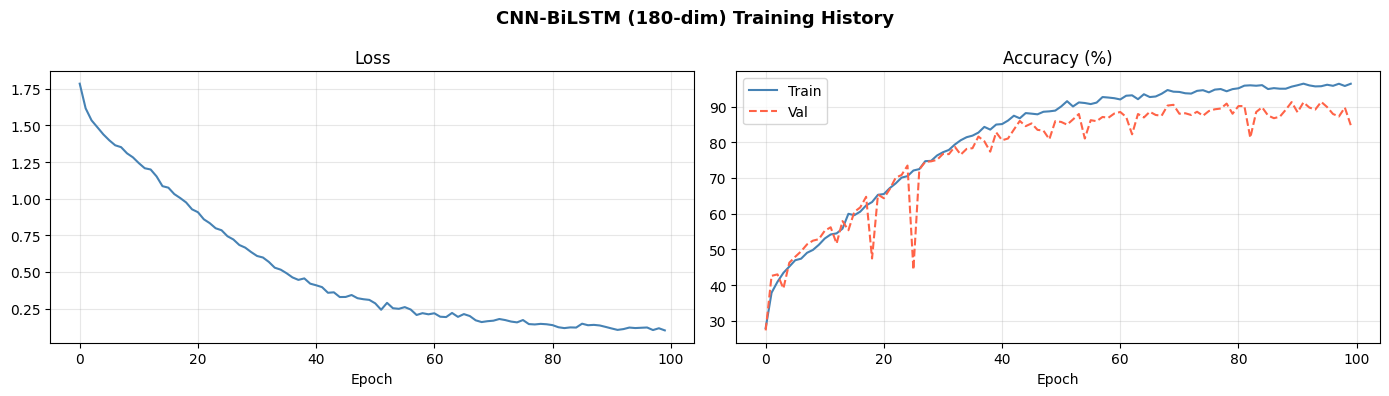


  CNN-BiLSTM (180-dim) - Test Results
  Accuracy:            0.9132
  F1 (macro):          0.9116
  F1 (weighted):       0.9132
  Precision (macro):   0.9144
  Recall (macro):      0.9102

  Per-class F1:
    angry       : 0.911  ██████████████████
    disgust     : 0.891  █████████████████
    fear        : 0.926  ██████████████████
    happy       : 0.923  ██████████████████
    neutral     : 0.929  ██████████████████
    sad         : 0.882  █████████████████
    surprised   : 0.918  ██████████████████

  Sklearn Classification Report:

              precision    recall  f1-score   support

       angry       0.97      0.86      0.91       185
     disgust       0.87      0.92      0.89       183
        fear       0.94      0.91      0.93       198
       happy       0.92      0.93      0.92       189
     neutral       0.91      0.95      0.93       298
         sad       0.89      0.88      0.88       188
   surprised       0.91      0.93      0.92       199

    accuracy       

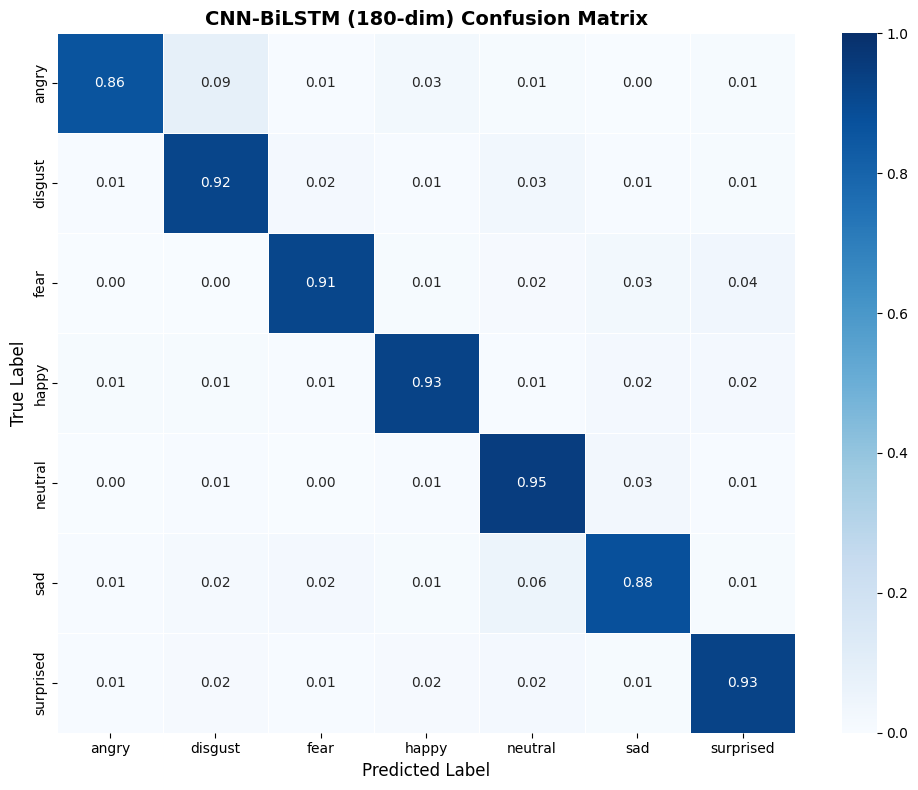

In [26]:
import torch
import torch.nn as nn
import time
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from evaluation.metrics import compute_metrics, print_report
from utils.config import EMOTIONS
from utils.visualization import plot_confusion_matrix

if 'paper_cnn_bilstm' in MODELS_TO_TRAIN:
    from models.paper_cnn_bilstm import PaperCNNBiLSTM
    import importlib
    import models.paper_cnn_bilstm as m_module
    importlib.reload(m_module)
    from models.paper_cnn_bilstm import PaperCNNBiLSTM

    print('\n=== Paper CNN-BiLSTM (180-dim features) ===')
    model = PaperCNNBiLSTM(
        input_features=X_tr_ref.shape[1],   # 180
        num_classes=len(set(y_tr_ref.tolist()))
    ).to(device)
    print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

    # Use same dataloaders as reference CNN
    train_dl_bilstm = DataLoader(FlatFeatureDataset(X_tr_ref, y_tr_ref),
                                  batch_size=64, shuffle=True,  num_workers=2)
    test_dl_bilstm  = DataLoader(FlatFeatureDataset(X_te_ref, y_te_ref),
                                  batch_size=64, shuffle=False, num_workers=2)

    optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)
    criterion = nn.CrossEntropyLoss()
    ckpt_path = f'{CHECKPOINT_DIR}/paper_cnn_bilstm_180_best.pt'
    best_val_acc  = 0.0
    patience_left = EARLY_STOP
    history       = {'train_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        model.train()
        train_loss = train_correct = train_total = 0
        for xb, yb in train_dl_bilstm:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out  = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            train_loss    += loss.item() * len(yb)
            train_correct += (out.argmax(1) == yb).sum().item()
            train_total   += len(yb)

        model.eval()
        val_correct = val_total = 0
        with torch.no_grad():
            for xb, yb in test_dl_bilstm:
                xb, yb = xb.to(device), yb.to(device)
                val_correct += (model(xb).argmax(1) == yb).sum().item()
                val_total   += len(yb)

        train_acc = train_correct / train_total
        val_acc   = val_correct   / val_total
        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch:3d}/{EPOCHS}  loss={train_loss/train_total:.4f}  '
              f'train={train_acc:.4f}  val={val_acc:.4f}  '
              f'gap={train_acc-val_acc:.4f}  {time.time()-t0:.1f}s')

        if val_acc > best_val_acc:
            best_val_acc  = val_acc
            patience_left = EARLY_STOP
            torch.save({'model_state': model.state_dict(), 'val_acc': val_acc}, ckpt_path)
            print(f'  ✓ Best val={val_acc:.4f} saved')
        else:
            patience_left -= 1
            print(f'  patience: {patience_left}/{EARLY_STOP}')
            if patience_left == 0:
                print(f'  Early stopping at epoch {epoch}')
                break

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history['train_loss'], color='steelblue')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(alpha=0.3)
    axes[1].plot([a*100 for a in history['train_acc']], label='Train', color='steelblue')
    axes[1].plot([a*100 for a in history['val_acc']],   label='Val',   color='tomato', linestyle='--')
    axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.suptitle('CNN-BiLSTM (180-dim) Training History', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    # Evaluate
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_dl_bilstm:
            all_preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
            all_labels.extend(yb.numpy())
    all_labels, all_preds = np.array(all_labels), np.array(all_preds)
    print_report(all_labels, all_preds, EMOTIONS, title='CNN-BiLSTM (180-dim) - Test Results')
    m = compute_metrics(all_labels, all_preds)
    all_results['CNN-BiLSTM (180-dim)'] = m
    fig = plot_confusion_matrix(m['confusion_matrix'], labels=m['present_labels'],
                                 title='CNN-BiLSTM (180-dim) Confusion Matrix')
    plt.show()

In [19]:
# This line is in the shared helpers cell — make sure it ran
all_results = {}

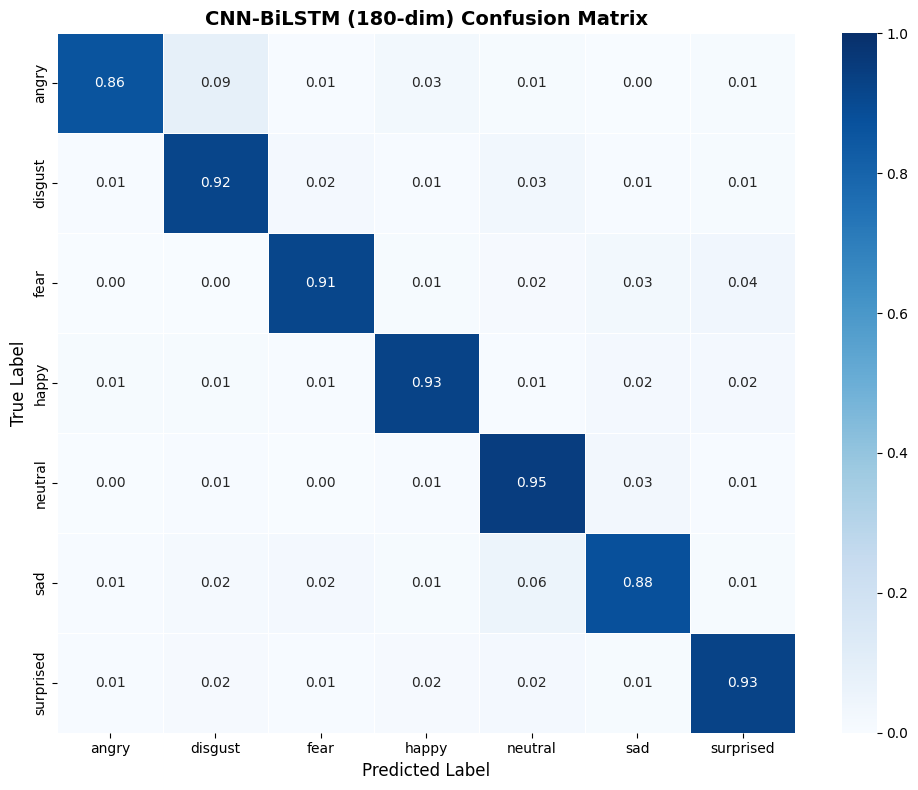

In [27]:
%matplotlib inline
import matplotlib.pyplot as plt
all_results['CNN-BiLSTM (180-dim)'] = m
fig = plot_confusion_matrix(m['confusion_matrix'], labels=m['present_labels'],
                            title='CNN-BiLSTM (180-dim) Confusion Matrix')
plt.show()

cross validation

In [28]:
# ── 5-Fold CV config ──────────────────────────────────────────
CV_MODELS = ['paper_cnn_bilstm']  # add 'svm', 'lr' etc as needed
K         = 5
CV_EARLY_STOP = 9999  # disable early stopping for CV

In [31]:
# ── 5-Fold CV ─────────────────────────────────────────────────
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from collections import Counter
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from evaluation.metrics import compute_metrics, print_report
from utils.config import EMOTIONS, EMOTION_TO_IDX

# Build full unaugmented dataset for splitting
print('Building full dataset for CV (no augmentation)...')
X_all, y_all = [], []
for path, label in tqdm(samples):
    if label not in EMOTION_TO_IDX:
        continue
    try:
        y_audio = load_and_pad(path)
        X_all.append(extract_paper_features_mean(y_audio))
        y_all.append(EMOTION_TO_IDX[label])
    except Exception as e:
        print(f'  [skip] {e}')

X_all = np.stack(X_all).astype(np.float32)
y_all = np.array(y_all, dtype=np.int64)
print(f'Full dataset: {X_all.shape}')

skf        = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
cv_results = {name: [] for name in CV_MODELS}

Building full dataset for CV (no augmentation)...


100%|██████████| 1440/1440 [01:17<00:00, 18.68it/s]


Full dataset: (1440, 182)


In [33]:
# ── CV loop ───────────────────────────────────────────────────
for model_name in CV_MODELS:
    print(f'\n{"="*60}')
    print(f'  {K}-Fold CV: {model_name}')
    print(f'{"="*60}')

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_all, y_all)):
        print(f'\n  Fold {fold+1}/{K}')

        # Split
        X_te = X_all[test_idx]
        y_te = y_all[test_idx]

        # Apply 4x augmentation to train fold only
        fold_train_samples = [samples[i] for i in train_idx]
        X_tr_list, y_tr_list = [], []
        for path, label in fold_train_samples:
            if label not in EMOTION_TO_IDX:
                continue
            idx = EMOTION_TO_IDX[label]
            try:
                y_audio = load_and_pad(path)

                # Original
                X_tr_list.append(extract_paper_features_mean(y_audio))
                y_tr_list.append(idx)

                # Noise
                y_noise = y_audio + 0.001 * np.random.randn(len(y_audio))
                X_tr_list.append(extract_paper_features_mean(y_noise.astype(np.float32)))
                y_tr_list.append(idx)

                # Time shift
                shift_amt = np.random.randint(int(22050 * 0.25))
                y_shift   = np.roll(y_audio, -shift_amt)
                y_shift[-shift_amt:] = 0
                X_tr_list.append(extract_paper_features_mean(y_shift))
                y_tr_list.append(idx)

                # Pitch shift
                y_pitch = augment_pitch(y_audio, pitch_factor=0.7)
                X_tr_list.append(extract_paper_features_mean(y_pitch))
                y_tr_list.append(idx)

            except Exception as e:
                pass

        X_tr = np.stack(X_tr_list).astype(np.float32)
        y_tr = np.array(y_tr_list, dtype=np.int64)
        print(f'    Train (aug): {X_tr.shape}  Test: {X_te.shape}')

        if model_name in ('svm', 'lr'):
            from models.baseline import build_svm, build_logistic_regression
            clf = build_svm() if model_name == 'svm' else build_logistic_regression()
            clf.fit(X_tr, y_tr)
            preds = clf.predict(X_te)
            m     = compute_metrics(y_te, preds)

        else:
            # Deep model
            from models.paper_cnn_bilstm import PaperCNNBiLSTM
            num_cls    = len(set(y_tr.tolist()))
            fold_model = PaperCNNBiLSTM(
                input_features=X_tr.shape[1],
                num_classes=num_cls
            ).to(device)

            # Weighted loss
            counts  = Counter(y_tr.tolist())
            total   = sum(counts.values())
            weights = torch.zeros(num_cls)
            for i, count in counts.items():
                weights[i] = total / (num_cls * count)
            criterion = nn.CrossEntropyLoss(weight=weights.to(device))
            optimizer = Adam(fold_model.parameters(), lr=1e-3, weight_decay=1e-6)
            scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5,
                                          patience=5, min_lr=1e-5)

            train_dl = DataLoader(FlatFeatureDataset(X_tr, y_tr),
                                   batch_size=64, shuffle=True, num_workers=2)
            test_dl  = DataLoader(FlatFeatureDataset(X_te, y_te),
                                   batch_size=64, shuffle=False, num_workers=2)

            best_acc      = 0.0
            patience_left = CV_EARLY_STOP
            ckpt_path     = f'{CHECKPOINT_DIR}/cv_{model_name}_fold{fold+1}.pt'

            for epoch in range(1, EPOCHS + 1):
                fold_model.train()
                train_correct = train_total = 0
                for xb, yb in train_dl:
                    xb, yb = xb.to(device), yb.to(device)
                    optimizer.zero_grad()
                    out  = fold_model(xb)
                    loss = criterion(out, yb)
                    loss.backward()
                    optimizer.step()
                    train_correct += (out.argmax(1) == yb).sum().item()
                    train_total   += len(yb)

                fold_model.eval()
                val_correct = val_total = 0
                with torch.no_grad():
                    for xb, yb in test_dl:
                        xb, yb = xb.to(device), yb.to(device)
                        val_correct += (fold_model(xb).argmax(1) == yb).sum().item()
                        val_total   += len(yb)

                train_acc = train_correct / train_total
                val_acc   = val_correct   / val_total
                scheduler.step(val_acc)

                if val_acc > best_acc:
                    best_acc      = val_acc
                    patience_left = CV_EARLY_STOP
                    torch.save({'model_state': fold_model.state_dict()}, ckpt_path)
                else:
                    patience_left -= 1
                    if patience_left == 0:
                        print(f'    Early stopping at epoch {epoch}')
                        break

                if epoch % 10 == 0:
                    print(f'    Epoch {epoch:3d}  train={train_acc:.4f}  '
                          f'val={val_acc:.4f}  best={best_acc:.4f}')

            ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
            fold_model.load_state_dict(ckpt['model_state'])
            fold_model.eval()
            preds, labels = [], []
            with torch.no_grad():
                for xb, yb in test_dl:
                    preds.extend(fold_model(xb.to(device)).argmax(1).cpu().numpy())
                    labels.extend(yb.numpy())
            m = compute_metrics(np.array(labels), np.array(preds))

        acc = m['accuracy']
        f1  = m['f1_weighted']
        cv_results[model_name].append({'accuracy': acc, 'f1_weighted': f1})
        print(f'    Fold {fold+1} — accuracy={acc:.4f}  f1={f1:.4f}')


  5-Fold CV: paper_cnn_bilstm

  Fold 1/5
    Train (aug): (4608, 182)  Test: (288, 182)
  PaperCNNBiLSTM: input=182  flat=160  classes=7
    Epoch  10  train=0.5284  val=0.4201  best=0.4479
    Epoch  20  train=0.6882  val=0.4792  best=0.5347
    Epoch  30  train=0.8064  val=0.5903  best=0.6111
    Epoch  40  train=0.9028  val=0.6458  best=0.6458
    Epoch  50  train=0.9258  val=0.6424  best=0.6667
    Epoch  60  train=0.9583  val=0.6632  best=0.6701
    Epoch  70  train=0.9642  val=0.6806  best=0.6875
    Epoch  80  train=0.9690  val=0.6910  best=0.6910
    Epoch  90  train=0.9748  val=0.6840  best=0.7014
    Epoch 100  train=0.9735  val=0.6910  best=0.7014
    Fold 1 — accuracy=0.7014  f1=0.6981

  Fold 2/5
    Train (aug): (4608, 182)  Test: (288, 182)
  PaperCNNBiLSTM: input=182  flat=160  classes=7
    Epoch  10  train=0.5163  val=0.4931  best=0.5139
    Epoch  20  train=0.6645  val=0.5590  best=0.5590
    Epoch  30  train=0.8056  val=0.6493  best=0.6667
    Epoch  40  train=0.8

In [34]:
# ── CV Summary ────────────────────────────────────────────────
print(f'\n{"="*60}')
print(f'  {K}-FOLD CV SUMMARY')
print(f'{"="*60}')
print(f'{"Model":<22} {"Mean Acc":>10} {"Std":>8} {"Mean F1":>10} {"Std":>8}')
print('-' * 60)
for name, scores in cv_results.items():
    accs = [s['accuracy']    for s in scores]
    f1s  = [s['f1_weighted'] for s in scores]
    print(f'{name:<22} {np.mean(accs):>10.4f} {np.std(accs):>8.4f} '
          f'{np.mean(f1s):>10.4f} {np.std(f1s):>8.4f}')
    print(f'  Per fold: {[f"{a:.4f}" for a in accs]}')


  5-FOLD CV SUMMARY
Model                    Mean Acc      Std    Mean F1      Std
------------------------------------------------------------
paper_cnn_bilstm           0.7240   0.0267     0.7222   0.0285
  Per fold: ['0.7396', '0.7014', '0.7674', '0.7396', '0.7014', '0.6944']


using mean-aggregated

In [59]:
from tqdm import tqdm
from utils.config import EMOTION_TO_IDX
from data.dataset_loader import train_val_test_split
from sklearn.preprocessing import StandardScaler

def build_paper_dataset(sample_list, augment=True, sr=22050, verbose=True):
    X_list, y_list = [], []
    it = tqdm(sample_list, desc='Extracting') if verbose else sample_list
    for path, label in it:
        if label not in EMOTION_TO_IDX:
            continue
        idx = EMOTION_TO_IDX[label]
        try:
            if augment:
                for feat in extract_all_augmentations_mean(path, sr):  # ← updated
                    X_list.append(feat)
                    y_list.append(idx)
            else:
                y_audio = load_and_pad(path, sr=sr)
                X_list.append(extract_paper_features_mean(y_audio, sr))  # ← updated
                y_list.append(idx)
        except Exception as e:
            if verbose: print(f'  [skip] {path}: {e}')
    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int64)
    print(f'  Shape: {X.shape}')
    return X, y


train_s, val_s, test_s = train_val_test_split(samples, val_split=0.1, test_split=0.1)

print('Building train set (4x augmentation)...')
X_train, y_train = build_paper_dataset(train_s, augment=True)
print('Building val set...')
X_val,   y_val   = build_paper_dataset(val_s,   augment=False)
print('Building test set...')
X_test,  y_test  = build_paper_dataset(test_s,  augment=False)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)
print(f'Normalized - train mean={X_train.mean():.4f}, std={X_train.std():.4f}')

num_classes = len(set(y_train.tolist()))
print(f'Classes: {num_classes}')

Split → train: 1152, val: 144, test: 144
Building train set (4x augmentation)...


Extracting: 100%|██████████| 1152/1152 [04:18<00:00,  4.46it/s]


  Shape: (4608, 182)
Building val set...


Extracting: 100%|██████████| 144/144 [00:06<00:00, 23.23it/s]


  Shape: (144, 182)
Building test set...


Extracting: 100%|██████████| 144/144 [00:05<00:00, 24.41it/s]

  Shape: (144, 182)
Normalized - train mean=0.0000, std=1.0000
Classes: 7


In [61]:
# ── Shared imports & helpers ───────────────────────────────────
import torch
import torch.nn as nn
import time
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from evaluation.metrics import compute_metrics, print_report
from utils.config import EMOTIONS
from utils.visualization import plot_confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Store results from all trained models for comparison
all_results = {}


class FlatFeatureDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_dl = DataLoader(FlatFeatureDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_dl   = DataLoader(FlatFeatureDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_dl  = DataLoader(FlatFeatureDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


def train_deep_model(model, name, epochs=EPOCHS, early_stop=EARLY_STOP):
    """Generic training loop for any deep model."""
    optimizer     = Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)
    scheduler     = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-5)
    criterion     = nn.CrossEntropyLoss()
    ckpt_path     = f'{CHECKPOINT_DIR}/{name}_best.pt'
    best_val_acc  = 0.0
    patience_left = early_stop
    history       = {'train_loss': [], 'train_acc': [], 'val_acc': []}

    print(f'\nTraining {name} for up to {epochs} epochs (early stop patience={early_stop})\n')

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        model.train()
        train_loss = train_correct = train_total = 0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out  = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            train_loss    += loss.item() * len(yb)
            train_correct += (out.argmax(1) == yb).sum().item()
            train_total   += len(yb)

        model.eval()
        val_correct = val_total = 0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                val_correct += (model(xb).argmax(1) == yb).sum().item()
                val_total   += len(yb)

        train_acc = train_correct / train_total
        val_acc   = val_correct   / val_total
        lr_now    = optimizer.param_groups[0]['lr']
        scheduler.step(val_acc)

        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch:3d}/{epochs}  loss={train_loss/train_total:.4f}  '
              f'train={train_acc:.4f}  val={val_acc:.4f}  '
              f'lr={lr_now:.2e}  gap={train_acc-val_acc:.4f}  {time.time()-t0:.1f}s')

        if val_acc > best_val_acc:
            best_val_acc  = val_acc
            patience_left = early_stop
            torch.save({
                'epoch': epoch, 'model_state': model.state_dict(),
                'val_acc': val_acc, 'scaler': scaler,
                'num_classes': num_classes, 'input_features': X_train.shape[1],
            }, ckpt_path)
            print(f'  ✓ Best val={val_acc:.4f} saved')
        else:
            patience_left -= 1
            print(f'  patience: {patience_left}/{early_stop}')
            if patience_left == 0:
                print(f'  Early stopping at epoch {epoch}')
                break

    # Plot training curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history['train_loss'], color='steelblue')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].grid(alpha=0.3)
    axes[1].plot([a*100 for a in history['train_acc']], label='Train', color='steelblue')
    axes[1].plot([a*100 for a in history['val_acc']],   label='Val',   color='tomato', linestyle='--')
    axes[1].set_title('Accuracy (%)')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.suptitle(f'{name} Training History', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Evaluate on test set
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, yb in test_dl:
            preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
            labels.extend(yb.numpy())

    preds  = np.array(preds)
    labels = np.array(labels)
    print_report(labels, preds, EMOTIONS, title=f'{name} - Test Results')

    m = compute_metrics(labels, preds)
    fig = plot_confusion_matrix(m['confusion_matrix'], labels=m['present_labels'],
                                 title=f'{name} Confusion Matrix')
    plt.show()
    return m, preds, labels

print('Helpers ready')

Device: cuda
Helpers ready


In [62]:
# ── Train Paper CNN-BiLSTM ────────────────────────────────────
if 'paper_cnn_bilstm' in MODELS_TO_TRAIN:
    from models.paper_cnn_bilstm import PaperCNNBiLSTM
    print('\n=== Paper CNN-BiLSTM ===')
    model = PaperCNNBiLSTM(input_features=X_train.shape[1], num_classes=num_classes).to(device)
    print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
    m, cnn_bilstm_preds, cnn_bilstm_labels = train_deep_model(model, 'paper_cnn_bilstm')
    all_results['CNN-BiLSTM'] = m
else:
    print('Skipping Paper CNN-BiLSTM')


=== Paper CNN-BiLSTM ===
  PaperCNNBiLSTM: input=182  flat=160  classes=7
Parameters: 237,671

Training paper_cnn_bilstm for up to 100 epochs (early stop patience=900)

Epoch   1/100  loss=1.6874  train=0.3398  val=0.3819  lr=1.00e-03  gap=-0.0421  0.9s
  ✓ Best val=0.3819 saved
Epoch   2/100  loss=1.4857  train=0.4329  val=0.4653  lr=1.00e-03  gap=-0.0323  0.8s
  ✓ Best val=0.4653 saved
Epoch   3/100  loss=1.4136  train=0.4690  val=0.4306  lr=1.00e-03  gap=0.0384  0.9s
  patience: 899/900
Epoch   4/100  loss=1.3233  train=0.4926  val=0.4653  lr=1.00e-03  gap=0.0273  0.9s
  patience: 898/900
Epoch   5/100  loss=1.2571  train=0.5278  val=0.4236  lr=1.00e-03  gap=0.1042  0.9s
  patience: 897/900
Epoch   6/100  loss=1.1854  train=0.5551  val=0.5208  lr=1.00e-03  gap=0.0343  0.9s
  ✓ Best val=0.5208 saved
Epoch   7/100  loss=1.1034  train=0.5911  val=0.4306  lr=1.00e-03  gap=0.1606  0.8s
  patience: 899/900
Epoch   8/100  loss=1.0448  train=0.6126  val=0.5903  lr=1.00e-03  gap=0.0224  1.1

In [56]:
# trying to match the reference cnn implementation track
if 'paper_cnn_bilstm' in MODELS_TO_TRAIN:
    from models.paper_cnn_bilstm import PaperCNNBiLSTM
    import importlib
    import models.paper_cnn_bilstm as m_module
    importlib.reload(m_module)
    from models.paper_cnn_bilstm import PaperCNNBiLSTM

    print('\n=== Paper CNN-BiLSTM (180-dim features) ===')
    model = PaperCNNBiLSTM(
        input_features=X_tr_ref.shape[1],   # 180
        num_classes=len(set(y_tr_ref.tolist()))
    ).to(device)
    print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

    # Use same dataloaders as reference CNN
    train_dl_bilstm = DataLoader(FlatFeatureDataset(X_train, y_train),
                                  batch_size=64, shuffle=True,  num_workers=2)
    test_dl_bilstm  = DataLoader(FlatFeatureDataset(X_test, y_test),
                                  batch_size=64, shuffle=False, num_workers=2)

    optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)
    criterion = nn.CrossEntropyLoss()
    ckpt_path = f'{CHECKPOINT_DIR}/paper_cnn_bilstm_180_best.pt'
    best_val_acc  = 0.0
    patience_left = EARLY_STOP
    history       = {'train_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        model.train()
        train_loss = train_correct = train_total = 0
        for xb, yb in train_dl_bilstm:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out  = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            train_loss    += loss.item() * len(yb)
            train_correct += (out.argmax(1) == yb).sum().item()
            train_total   += len(yb)

        model.eval()
        val_correct = val_total = 0
        with torch.no_grad():
            for xb, yb in test_dl_bilstm:
                xb, yb = xb.to(device), yb.to(device)
                val_correct += (model(xb).argmax(1) == yb).sum().item()
                val_total   += len(yb)

        train_acc = train_correct / train_total
        val_acc   = val_correct   / val_total
        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch:3d}/{EPOCHS}  loss={train_loss/train_total:.4f}  '
              f'train={train_acc:.4f}  val={val_acc:.4f}  '
              f'gap={train_acc-val_acc:.4f}  {time.time()-t0:.1f}s')

        if val_acc > best_val_acc:
            best_val_acc  = val_acc
            patience_left = EARLY_STOP
            torch.save({'model_state': model.state_dict(), 'val_acc': val_acc}, ckpt_path)
            print(f'  ✓ Best val={val_acc:.4f} saved')
        else:
            patience_left -= 1
            print(f'  patience: {patience_left}/{EARLY_STOP}')
            if patience_left == 0:
                print(f'  Early stopping at epoch {epoch}')
                break

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history['train_loss'], color='steelblue')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(alpha=0.3)
    axes[1].plot([a*100 for a in history['train_acc']], label='Train', color='steelblue')
    axes[1].plot([a*100 for a in history['val_acc']],   label='Val',   color='tomato', linestyle='--')
    axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.suptitle('CNN-BiLSTM (180-dim) Training History', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    # Evaluate
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_dl_bilstm:
            all_preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
            all_labels.extend(yb.numpy())
    all_labels, all_preds = np.array(all_labels), np.array(all_preds)
    print_report(all_labels, all_preds, EMOTIONS, title='CNN-BiLSTM (180-dim) - Test Results')
    m = compute_metrics(all_labels, all_preds)
    all_results['CNN-BiLSTM (180-dim)'] = m
    fig = plot_confusion_matrix(m['confusion_matrix'], labels=m['present_labels'],
                                 title='CNN-BiLSTM (180-dim) Confusion Matrix')
    plt.show()


=== Paper CNN-BiLSTM (180-dim features) ===
  PaperCNNBiLSTM: input=180  flat=160  classes=7
Parameters: 237,671
Epoch   1/100  loss=1.7262  train=0.3186  val=0.4931  gap=-0.1745  1.3s
  ✓ Best val=0.4931 saved
Epoch   2/100  loss=1.5529  train=0.3995  val=0.4583  gap=-0.0588  1.1s
  patience: 899/900
Epoch   3/100  loss=1.4456  train=0.4468  val=0.5625  gap=-0.1157  0.9s
  ✓ Best val=0.5625 saved
Epoch   4/100  loss=1.3753  train=0.4742  val=0.4167  gap=0.0575  0.9s
  patience: 899/900
Epoch   5/100  loss=1.2886  train=0.5104  val=0.5278  gap=-0.0174  0.9s
  patience: 898/900
Epoch   6/100  loss=1.2074  train=0.5399  val=0.5903  gap=-0.0503  0.9s
  ✓ Best val=0.5903 saved
Epoch   7/100  loss=1.1441  train=0.5731  val=0.5486  gap=0.0245  0.9s
  patience: 899/900
Epoch   8/100  loss=1.0552  train=0.6053  val=0.6667  gap=-0.0614  0.9s
  ✓ Best val=0.6667 saved
Epoch   9/100  loss=1.0188  train=0.6189  val=0.5833  gap=0.0356  0.9s
  patience: 899/900
Epoch  10/100  loss=0.9513  train=0.6

In [31]:
def build_frame_dataset(sample_list, augment=True, sr=22050, verbose=True):
    from tqdm import tqdm
    from utils.config import EMOTION_TO_IDX

    X_list, y_list = [], []
    it = tqdm(sample_list, desc='Extracting frames') if verbose else sample_list

    for path, label in it:
        if label not in EMOTION_TO_IDX:
            continue
        idx = EMOTION_TO_IDX[label]
        try:
            y_audio = load_and_pad(path, sr=sr)
            if augment:
                y_na   = augment_noise(y_audio)
                y_pa   = augment_pitch(y_audio, sr=sr)
                y_napa = augment_pitch(augment_noise(y_audio), sr=sr)
                for y_aug in [y_na, y_pa, y_napa, y_audio]:
                    X_list.append(extract_frame_features(y_aug, sr))
                    y_list.append(idx)
            else:
                X_list.append(extract_frame_features(y_audio, sr))
                y_list.append(idx)
        except Exception as e:
            if verbose: print(f'  [skip] {path}: {e}')

    X = np.stack(X_list).astype(np.float32)  # (N, T, 34)
    y = np.array(y_list, dtype=np.int64)
    print(f'  Shape: {X.shape}')             # (N, 108, 34)
    return X, y


print('Building frame-level dataset...')
X_train_frame, y_train_frame = build_frame_dataset(train_s, augment=True)
X_val_frame,   y_val_frame   = build_frame_dataset(val_s,   augment=False)
X_test_frame,  y_test_frame  = build_frame_dataset(test_s,  augment=False)
print(f'Train: {X_train_frame.shape}  Val: {X_val_frame.shape}  Test: {X_test_frame.shape}')

Building frame-level dataset...


Extracting frames:   0%|          | 1/1152 [00:00<01:56,  9.89it/s]

  [skip] data/raw/ravdess/Actor_08/03-01-08-02-01-02-08.wav: name 'extract_frame_features_mean' is not defined
  [skip] data/raw/ravdess/Actor_20/03-01-07-02-02-01-20.wav: name 'extract_frame_features_mean' is not defined


Extracting frames:   0%|          | 3/1152 [00:00<01:23, 13.73it/s]

  [skip] data/raw/ravdess/Actor_18/03-01-02-01-01-02-18.wav: name 'extract_frame_features_mean' is not defined
  [skip] data/raw/ravdess/Actor_08/03-01-04-01-01-02-08.wav: name 'extract_frame_features_mean' is not defined


...

Extracting frames:  58%|█████▊    | 666/1152 [00:36<00:24, 19.59it/s]

  [skip] data/raw/ravdess/Actor_19/03-01-01-01-01-02-19.wav: name 'extract_frame_features_mean' is not defined
  [skip] data/raw/ravdess/Actor_06/03-01-03-02-01-01-06.wav: name 'extract_frame_features_mean' is not defined
  [skip] data/raw/ravdess/Actor_01/03-01-01-01-02-01-01.wav: name 'extract_frame_features_mean' is not defined
  [skip] data/raw/ravdess/Actor_05/03-01-01-01-02-01-05.wav: name 'extract_frame_features_mean' is not defined


Extracting frames:  58%|█████▊    | 670/1152 [00:37<00:26, 18.10it/s]

  [skip] data/raw/ravdess/Actor_19/03-01-03-02-02-02-19.wav: name 'extract_frame_features_mean' is not defined
  [skip] data/raw/ravdess/Actor_23/03-01-03-01-01-02-23.wav: name 'extract_frame_features_mean' is not defined
  [skip] data/raw/ravdess/Actor_14/03-01-01-01-01-01-14.wav: name 'extract_frame_features_mean' is not defined
  [skip] data/raw/ravdess/Actor_24/03-01-03-02-01-01-24.wav: name 'extract_frame_features_mean' is not defined


KeyboardInterrupt: 

In [24]:
class PaperCNNBiLSTM_Frame(nn.Module):
    """
    CNN-BiLSTM operating on per-frame feature sequences.
    Input: (B, T, n_features) e.g. (64, 108, 34)
    Conv1d treats features as channels, time as length.
    """
    def __init__(self, n_features=34, n_frames=108, num_classes=7):
        super().__init__()

        # Input: (B, T, n_features) → permute to (B, n_features, T) for Conv1d
        self.block1 = nn.Sequential(
            nn.Conv1d(n_features, 128, kernel_size=5, padding='same'),
            nn.BatchNorm1d(128), nn.MaxPool1d(2),
        )
        self.block2 = nn.Sequential(
            nn.Conv1d(128, 128, kernel_size=5, padding='same'),
            nn.BatchNorm1d(128), nn.MaxPool1d(2), nn.Dropout(0.2),
        )
        self.block3 = nn.Sequential(
            nn.Conv1d(128, 64, kernel_size=5, padding='same'),
            nn.BatchNorm1d(64), nn.MaxPool1d(2),
        )
        self.block4 = nn.Sequential(
            nn.Conv1d(64, 64, kernel_size=3, padding='same'),
            nn.BatchNorm1d(64), nn.MaxPool1d(2), nn.Dropout(0.2),
        )
        self.bilstm = nn.LSTM(
            input_size=64, hidden_size=64,
            num_layers=1, batch_first=True, bidirectional=True,
        )
        self.block5 = nn.Sequential(
            nn.Conv1d(128, 32, kernel_size=3, padding='same'),
            nn.BatchNorm1d(32), nn.MaxPool1d(2), nn.Dropout(0.2),
        )

        # Compute flat size dynamically
        with torch.no_grad():
            d = torch.zeros(1, n_features, n_frames)
            d = self.block4(self.block3(self.block2(self.block1(d))))
            d, _ = self.bilstm(d.permute(0, 2, 1))
            d = self.block5(d.permute(0, 2, 1))
            flat = d.flatten(1).shape[1]
        print(f'  flat_size: {flat}')

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat, 128), nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # x: (B, T, n_features) → (B, n_features, T) for Conv1d
        x = x.permute(0, 2, 1)
        x = self.block4(self.block3(self.block2(self.block1(x))))
        x, _ = self.bilstm(x.permute(0, 2, 1))
        x = self.block5(x.permute(0, 2, 1))
        return self.head(x)


# Dataset wrapper for sequence input
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # (N, T, features)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


# Build dataloaders
train_dl_frame = DataLoader(SequenceDataset(X_train_frame, y_train_frame),
                             batch_size=64, shuffle=True,  num_workers=2)
val_dl_frame   = DataLoader(SequenceDataset(X_val_frame,   y_val_frame),
                             batch_size=64, shuffle=False, num_workers=2)
test_dl_frame  = DataLoader(SequenceDataset(X_test_frame,  y_test_frame),
                             batch_size=64, shuffle=False, num_workers=2)

# Build model
n_features  = X_train_frame.shape[2]   # 34
n_frames    = X_train_frame.shape[1]   # 108
num_classes = len(set(y_train_frame.tolist()))

frame_model = PaperCNNBiLSTM_Frame(
    n_features=n_features,
    n_frames=n_frames,
    num_classes=num_classes
).to(device)
print(f'Parameters: {sum(p.numel() for p in frame_model.parameters()):,}')

  flat_size: 96
Parameters: 250,599


In [25]:
# ── Train CNN-BiLSTM (frame-level features) ───────────────────
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time

optimizer     = Adam(frame_model.parameters(), lr=1e-3, weight_decay=1e-6)
scheduler     = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-5)
criterion     = nn.CrossEntropyLoss()
ckpt_path     = f'{CHECKPOINT_DIR}/cnn_bilstm_frame_best.pt'
best_val_acc  = 0.0
patience_left = EARLY_STOP
history       = {'train_loss': [], 'train_acc': [], 'val_acc': []}

print(f'\nTraining CNN-BiLSTM (frame-level) for up to {EPOCHS} epochs\n')

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    frame_model.train()
    train_loss = train_correct = train_total = 0
    for xb, yb in train_dl_frame:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = frame_model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * len(yb)
        train_correct += (out.argmax(1) == yb).sum().item()
        train_total   += len(yb)

    frame_model.eval()
    val_correct = val_total = 0
    with torch.no_grad():
        for xb, yb in val_dl_frame:
            xb, yb = xb.to(device), yb.to(device)
            val_correct += (frame_model(xb).argmax(1) == yb).sum().item()
            val_total   += len(yb)

    train_acc = train_correct / train_total
    val_acc   = val_correct   / val_total
    scheduler.step(val_acc)
    history['train_loss'].append(train_loss / train_total)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch:3d}/{EPOCHS}  loss={train_loss/train_total:.4f}  '
          f'train={train_acc:.4f}  val={val_acc:.4f}  '
          f'gap={train_acc-val_acc:.4f}  {time.time()-t0:.1f}s')

    if val_acc > best_val_acc:
        best_val_acc  = val_acc
        patience_left = EARLY_STOP
        torch.save({'model_state': frame_model.state_dict(), 'val_acc': val_acc}, ckpt_path)
        print(f'  ✓ Best val={val_acc:.4f} saved')
    else:
        patience_left -= 1
        print(f'  patience: {patience_left}/{EARLY_STOP}')
        if patience_left == 0:
            print(f'  Early stopping at epoch {epoch}')
            break


Training CNN-BiLSTM (frame-level) for up to 100 epochs

Epoch   1/100  loss=1.6457  train=0.3670  val=0.4167  gap=-0.0497  1.0s
  ✓ Best val=0.4167 saved
Epoch   2/100  loss=1.2152  train=0.5551  val=0.5278  gap=0.0273  1.1s
  ✓ Best val=0.5278 saved
Epoch   3/100  loss=0.9634  train=0.6465  val=0.5903  gap=0.0562  1.3s
  ✓ Best val=0.5903 saved
Epoch   4/100  loss=0.7566  train=0.7237  val=0.5625  gap=0.1612  1.4s
  patience: 899/900
Epoch   5/100  loss=0.5928  train=0.7843  val=0.4722  gap=0.3121  1.3s
  patience: 898/900
Epoch   6/100  loss=0.4823  train=0.8296  val=0.5694  gap=0.2602  1.0s
  patience: 897/900
Epoch   7/100  loss=0.3877  train=0.8678  val=0.5833  gap=0.2845  0.9s
  patience: 896/900
Epoch   8/100  loss=0.3373  train=0.8848  val=0.5903  gap=0.2945  0.9s
  patience: 895/900
Epoch   9/100  loss=0.2751  train=0.9084  val=0.6250  gap=0.2834  1.0s
  ✓ Best val=0.6250 saved
Epoch  10/100  loss=0.2373  train=0.9169  val=0.5417  gap=0.3752  1.0s
  patience: 899/900
Epoch  1

In [26]:
# ── Evaluate ──────────────────────────────────────────────────
from evaluation.metrics import compute_metrics, print_report
from utils.visualization import plot_confusion_matrix
from utils.config import EMOTIONS

ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
frame_model.load_state_dict(ckpt['model_state'])
frame_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_dl_frame:
        all_preds.extend(frame_model(xb.to(device)).argmax(1).cpu().numpy())
        all_labels.extend(yb.numpy())

all_labels, all_preds = np.array(all_labels), np.array(all_preds)
print_report(all_labels, all_preds, EMOTIONS, title='CNN-BiLSTM (frame-level) - Test Results')

m = compute_metrics(all_labels, all_preds)
all_results['CNN-BiLSTM (frame)'] = m

fig = plot_confusion_matrix(
    m['confusion_matrix'],
    labels=m['present_labels'],
    title='CNN-BiLSTM (frame-level) Confusion Matrix'
)
plt.show()


  CNN-BiLSTM (frame-level) - Test Results
  Accuracy:            0.6944
  F1 (macro):          0.6699
  F1 (weighted):       0.6921
  Precision (macro):   0.6839
  Recall (macro):      0.6671

  Per-class F1:
    angry       : 0.727  ██████████████
    disgust     : 0.706  ██████████████
    fear        : 0.621  ████████████
    happy       : 0.488  █████████
    neutral     : 0.835  ████████████████
    sad         : 0.581  ███████████
    surprised   : 0.732  ██████████████

  Sklearn Classification Report:

              precision    recall  f1-score   support

       angry       0.86      0.63      0.73        19
     disgust       0.67      0.75      0.71        16
        fear       0.60      0.64      0.62        14
       happy       0.50      0.48      0.49        21
     neutral       0.77      0.92      0.84        36
         sad       0.56      0.60      0.58        15
   surprised       0.83      0.65      0.73        23

    accuracy                           0.69      

In [29]:
# ── Training curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history['train_loss'], color='steelblue')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)

axes[1].plot([a*100 for a in history['train_acc']], label='Train', color='steelblue')
axes[1].plot([a*100 for a in history['val_acc']],   label='Val',   color='tomato', linestyle='--')
axes[1].set_title('Accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('CNN-BiLSTM (frame-level) Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Compare All Trained Models

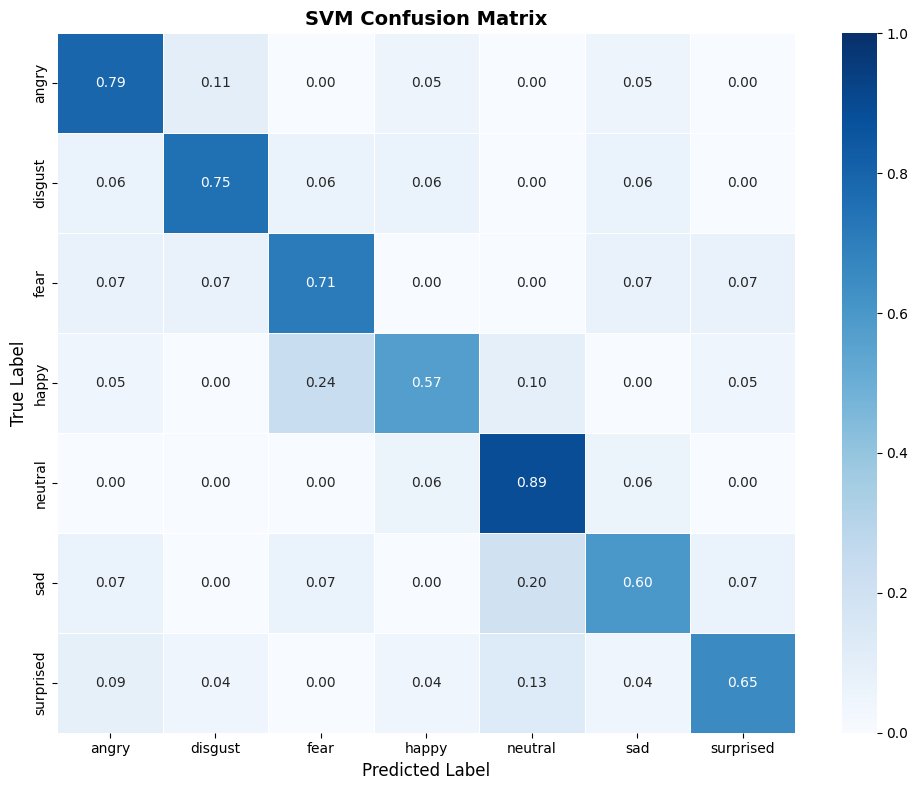

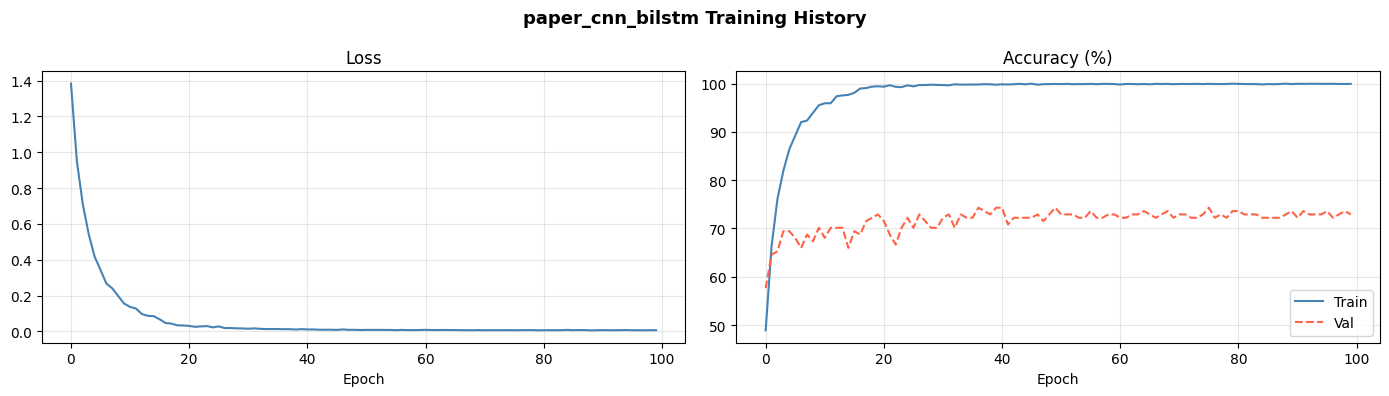

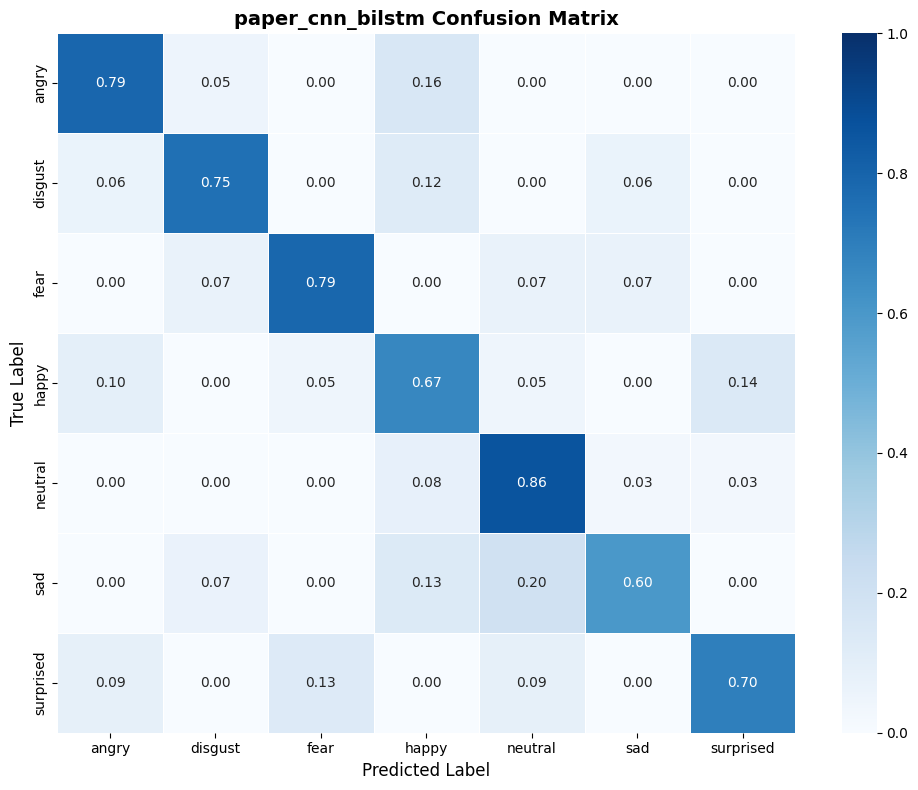

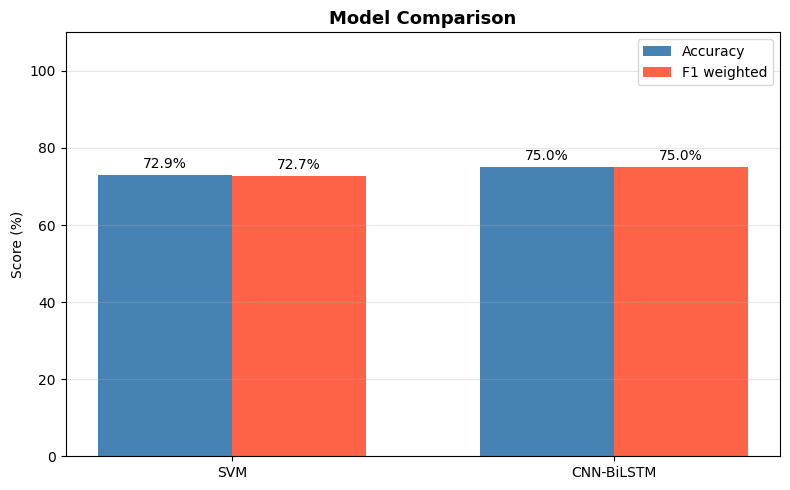

Model                    Accuracy   F1 macro  F1 weighted
--------------------------------------------------------
CNN-BiLSTM                 0.7500     0.7390       0.7498
SVM                        0.7292     0.7072       0.7270


In [21]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

if not all_results:
    print('No results yet — train at least one model first')
else:
    names = list(all_results.keys())
    acc   = [all_results[m].get('accuracy', 0) * 100    for m in names]
    f1    = [all_results[m].get('f1_weighted', 0) * 100 for m in names]
    x, w  = np.arange(len(names)), 0.35

    fig, ax = plt.subplots(figsize=(max(8, len(names) * 2), 5))
    b1 = ax.bar(x - w/2, acc, w, label='Accuracy',    color='steelblue')
    b2 = ax.bar(x + w/2, f1,  w, label='F1 weighted', color='tomato')
    ax.bar_label(b1, fmt='%.1f%%', padding=3)
    ax.bar_label(b2, fmt='%.1f%%', padding=3)
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_ylim(0, 110)
    ax.set_ylabel('Score (%)')
    ax.set_title('Model Comparison', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'{"Model":<22} {"Accuracy":>10} {"F1 macro":>10} {"F1 weighted":>12}')
    print('-' * 56)
    for name in sorted(names, key=lambda n: -all_results[n].get('f1_weighted', 0)):
        m = all_results[name]
        print(f'{name:<22} {m.get("accuracy",0):>10.4f} {m.get("f1_macro",0):>10.4f} {m.get("f1_weighted",0):>12.4f}')

## 8. Cross Validation
Run k-fold cross validation for a more reliable accuracy estimate than a single train/test split. Change `CV_MODELS` to select which models to evaluate.

In [9]:
# ── Choose which models to run CV on ──────────────────────────
CV_MODELS = [
    'paper_cnn_bilstm',
    'svm',
]
# Options: 'paper_cnn_bilstm', 'svm', 'lr', 'cnn'

K = 5  # number of folds

In [16]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from collections import Counter
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from evaluation.metrics import compute_metrics
from utils.config import EMOTION_TO_IDX

# Build full unaugmented dataset for CV splitting
print('Building full dataset for CV...')
X_all, y_all = build_paper_dataset(samples, augment=False, verbose=False)
print(f'Full dataset: {X_all.shape}')

skf        = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
cv_results = {name: [] for name in CV_MODELS}


def build_cv_model(name, input_features, num_classes):
    """Return an untrained model for the given name."""
    if name == 'paper_cnn_bilstm':
        from models.paper_cnn_bilstm import PaperCNNBiLSTM
        return PaperCNNBiLSTM(input_features=input_features, num_classes=num_classes).to(device)
    elif name == 'cnn':
        from models.cnn import build_cnn
        from utils.config import CNNConfig
        return build_cnn(CNNConfig(num_classes=num_classes)).to(device)
    else:
        return None  # SVM and LR are handled separately


def train_cv_fold(model, X_tr, y_tr, X_te, y_te, fold, name):
    """Train one deep model fold and return accuracy + f1."""
    counts  = Counter(y_tr.tolist())
    total   = sum(counts.values())
    num_cls = len(counts)
    weights = torch.zeros(num_cls)
    for idx, count in counts.items():
        weights[idx] = total / (num_cls * count)
    criterion = nn.CrossEntropyLoss(weight=weights.to(device))
    optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-5)

    train_dl = DataLoader(FlatFeatureDataset(X_tr, y_tr), batch_size=64, shuffle=True,  num_workers=2)
    test_dl  = DataLoader(FlatFeatureDataset(X_te, y_te), batch_size=64, shuffle=False, num_workers=2)

    best_acc      = 0.0
    patience_left = 999
    ckpt_path     = f'{CHECKPOINT_DIR}/cv_{name}_fold{fold+1}.pt'

    for epoch in range(1, 101):
        model.train()
        train_correct = train_total = 0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out  = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            train_correct += (out.argmax(1) == yb).sum().item()
            train_total   += len(yb)

        model.eval()
        val_correct = val_total = 0
        with torch.no_grad():
            for xb, yb in test_dl:
                xb, yb = xb.to(device), yb.to(device)
                val_correct += (model(xb).argmax(1) == yb).sum().item()
                val_total   += len(yb)

        train_acc = train_correct / train_total
        val_acc   = val_correct   / val_total
        scheduler.step(val_acc)

        if val_acc > best_acc:
            best_acc      = val_acc
            patience_left = 15
            torch.save({'model_state': model.state_dict()}, ckpt_path)
        else:
            patience_left -= 1
            if patience_left == 0:
                print(f'    Early stopping at epoch {epoch}')
                break

        if epoch % 10 == 0:
            print(f'    Epoch {epoch:3d}  train={train_acc:.4f}  val={val_acc:.4f}  best={best_acc:.4f}')

    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, yb in test_dl:
            preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
            labels.extend(yb.numpy())
    return compute_metrics(np.array(labels), np.array(preds))


# ── Run CV for each selected model ────────────────────────────
for model_name in CV_MODELS:
    print(f'\n{"="*60}')
    print(f'  {K}-Fold CV: {model_name}')
    print(f'{"="*60}')

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_all, y_all)):
        print(f'\n  Fold {fold+1}/{K}')

        X_te = X_all[test_idx]
        y_te = y_all[test_idx]

        # Fit scaler on this fold's train split
        fold_scaler = StandardScaler()

        if model_name in ('svm', 'lr'):
            # Classical models — no augmentation needed
            X_tr = fold_scaler.fit_transform(X_all[train_idx])
            X_te = fold_scaler.transform(X_te)

            from models.baseline import build_svm, build_logistic_regression
            clf = build_svm() if model_name == 'svm' else build_logistic_regression()
            # Scaler already applied so just use the clf directly
            from sklearn.svm import SVC
            from sklearn.linear_model import LogisticRegression
            if model_name == 'svm':
                clf = SVC(C=10, gamma='scale', probability=True)
            else:
                clf = LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs',
                                         multi_class='multinomial', n_jobs=-1)
            clf.fit(X_tr, y_all[train_idx])
            preds = clf.predict(X_te)
            m     = compute_metrics(y_te, preds)

        else:
            # Deep models — apply 4x augmentation to train fold
            fold_train_samples = [samples[i] for i in train_idx]
            X_tr_aug, y_tr_aug = build_paper_dataset(fold_train_samples, augment=True, verbose=False)
            X_tr_aug = fold_scaler.fit_transform(X_tr_aug)
            X_te     = fold_scaler.transform(X_te)
            print(f'    Train (aug): {X_tr_aug.shape}  Test: {X_te.shape}')

            num_classes = len(set(y_tr_aug.tolist()))
            model       = build_cv_model(model_name, X_tr_aug.shape[1], num_classes)
            m           = train_cv_fold(model,
                                        torch.tensor(X_tr_aug), torch.tensor(y_tr_aug),
                                        torch.tensor(X_te),     torch.tensor(y_te),
                                        fold, model_name)

        acc = m['accuracy']
        f1  = m['f1_weighted']
        cv_results[model_name].append({'accuracy': acc, 'f1_weighted': f1})
        print(f'    Fold {fold+1} — accuracy={acc:.4f}  f1={f1:.4f}')

# ── Summary table ─────────────────────────────────────────────
print(f'\n{"="*60}')
print(f'  CV SUMMARY')
print(f'{"="*60}')
print(f'{"Model":<22} {"Mean Acc":>10} {"Std Acc":>10} {"Mean F1":>10} {"Std F1":>10}')
print('-' * 62)
for name, scores in cv_results.items():
    accs = [s['accuracy']    for s in scores]
    f1s  = [s['f1_weighted'] for s in scores]
    print(f'{name:<22} {np.mean(accs):>10.4f} {np.std(accs):>10.4f} '
          f'{np.mean(f1s):>10.4f} {np.std(f1s):>10.4f}')

Building full dataset for CV...
  Shape: (1440, 3672)
Full dataset: (1440, 3672)

  5-Fold CV: paper_cnn_bilstm

  Fold 1/5
  Shape: (4608, 3672)
    Train (aug): (4608, 3672)  Test: (288, 3672)
  PaperCNNBiLSTM: input=3672  flat=3648  classes=7


/tmp/ipykernel_3696/2752277482.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(X, dtype=torch.float32)
/tmp/ipykernel_3696/2752277482.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(y, dtype=torch.long)


    Epoch  10  train=0.9431  val=0.7465  best=0.7465
    Epoch  20  train=0.9931  val=0.7257  best=0.7535
    Epoch  30  train=0.9972  val=0.7431  best=0.7708
    Early stopping at epoch 36
    Fold 1 — accuracy=0.7708  f1=0.7692

  Fold 2/5
  Shape: (4608, 3672)
    Train (aug): (4608, 3672)  Test: (288, 3672)
  PaperCNNBiLSTM: input=3672  flat=3648  classes=7


/tmp/ipykernel_3696/2752277482.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(X, dtype=torch.float32)
/tmp/ipykernel_3696/2752277482.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(y, dtype=torch.long)


    Epoch  10  train=0.9436  val=0.7639  best=0.7674
    Epoch  20  train=0.9924  val=0.7535  best=0.7674
    Early stopping at epoch 23
    Fold 2 — accuracy=0.7674  f1=0.7636

  Fold 3/5
  Shape: (4608, 3672)
    Train (aug): (4608, 3672)  Test: (288, 3672)
  PaperCNNBiLSTM: input=3672  flat=3648  classes=7


...

    Epoch  10  train=0.9384  val=0.7222  best=0.7326
    Epoch  20  train=0.9920  val=0.7153  best=0.7431
    Epoch  30  train=0.9959  val=0.7465  best=0.7500
    Epoch  40  train=0.9987  val=0.7569  best=0.7708
    Epoch  50  train=0.9987  val=0.7674  best=0.7743
    Early stopping at epoch 60
    Fold 3 — accuracy=0.7743  f1=0.7686

  Fold 4/5
  Shape: (4608, 3672)
    Train (aug): (4608, 3672)  Test: (288, 3672)
  PaperCNNBiLSTM: input=3672  flat=3648  classes=7


/tmp/ipykernel_3696/2752277482.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(X, dtype=torch.float32)
/tmp/ipykernel_3696/2752277482.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(y, dtype=torch.long)


    Epoch  10  train=0.9373  val=0.7326  best=0.7778
    Epoch  20  train=0.9887  val=0.7535  best=0.7917
    Epoch  30  train=0.9937  val=0.7674  best=0.7986
    Epoch  40  train=0.9987  val=0.7951  best=0.8090
    Epoch  50  train=0.9993  val=0.8021  best=0.8160
    Epoch  60  train=0.9989  val=0.7951  best=0.8160
    Early stopping at epoch 63
    Fold 4 — accuracy=0.8160  f1=0.8098

  Fold 5/5
  Shape: (4608, 3672)
    Train (aug): (4608, 3672)  Test: (288, 3672)
  PaperCNNBiLSTM: input=3672  flat=3648  classes=7


/tmp/ipykernel_3696/2752277482.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(X, dtype=torch.float32)
/tmp/ipykernel_3696/2752277482.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(y, dtype=torch.long)


    Epoch  10  train=0.9373  val=0.7118  best=0.7431
    Epoch  20  train=0.9857  val=0.7812  best=0.7812
    Epoch  30  train=0.9974  val=0.7743  best=0.7847
    Epoch  40  train=0.9978  val=0.8090  best=0.8090
    Epoch  50  train=0.9980  val=0.7917  best=0.8090
    Early stopping at epoch 55
    Fold 5 — accuracy=0.8090  f1=0.8047

  5-Fold CV: svm

  Fold 1/5
    Fold 1 — accuracy=0.6875  f1=0.6820

  Fold 2/5
    Fold 2 — accuracy=0.6806  f1=0.6779

  Fold 3/5
    Fold 3 — accuracy=0.7014  f1=0.6916

  Fold 4/5
    Fold 4 — accuracy=0.7049  f1=0.6968

  Fold 5/5
    Fold 5 — accuracy=0.6771  f1=0.6684

  CV SUMMARY
Model                    Mean Acc    Std Acc    Mean F1     Std F1
--------------------------------------------------------------
paper_cnn_bilstm           0.7875     0.0206     0.7832     0.0198
svm                        0.6903     0.0111     0.6833     0.0100


## 9. Predict on Your Own Audio

In [ ]:
# Choose which trained model to use for prediction
PREDICT_WITH = 'paper_cnn_bilstm'   # must be in MODELS_TO_TRAIN

from google.colab import files
import IPython.display as ipd
uploaded   = files.upload()
audio_path = list(uploaded.keys())[0]
print('Uploaded:', audio_path)
ipd.display(ipd.Audio(audio_path))

In [ ]:
%matplotlib inline
import torch
import numpy as np
import matplotlib.pyplot as plt
from utils.config import IDX_TO_EMOTION

if PREDICT_WITH == 'paper_cnn_bilstm':
    from models.paper_cnn_bilstm import PaperCNNBiLSTM
    ckpt = torch.load(f'{CHECKPOINT_DIR}/paper_cnn_bilstm_best.pt', map_location=device, weights_only=False)
    pred_model = PaperCNNBiLSTM(input_features=ckpt['input_features'], num_classes=ckpt['num_classes']).to(device)
    pred_model.load_state_dict(ckpt['model_state'])
    pred_scaler = ckpt['scaler']
    pred_model.eval()

    y_audio = load_and_pad(audio_path)
    feat    = extract_paper_features(y_audio)
    feat_sc = pred_scaler.transform(feat.reshape(1, -1))
    x_in    = torch.tensor(feat_sc, dtype=torch.float32).to(device)

    with torch.no_grad():
        probs = torch.softmax(pred_model(x_in), dim=1).squeeze().cpu().numpy()

elif PREDICT_WITH in ('svm', 'lr'):
    from models.baseline import load_baseline
    bl = load_baseline(f'{CHECKPOINT_DIR}/{PREDICT_WITH}_baseline.pkl')
    y_audio = load_and_pad(audio_path)
    feat    = extract_paper_features(y_audio)
    feat_sc = scaler.transform(feat.reshape(1, -1))
    probs   = bl.predict_proba(feat_sc).squeeze()

else:
    print(f'Prediction not yet wired up for {PREDICT_WITH}')
    probs = None

if probs is not None:
    present_indices = sorted(set(y_train.tolist()))
    present_names   = [IDX_TO_EMOTION[i] for i in present_indices]
    pred_emotion    = present_names[probs.argmax()]
    confidence      = probs.max()

    print(f'Predicted : {pred_emotion.upper()}')
    print(f'Confidence: {confidence*100:.1f}%')

    order        = np.argsort(probs)[::-1]
    sorted_names = [present_names[i] for i in order]
    sorted_probs = probs[order]
    bar_colors   = ['gold' if n == pred_emotion else 'steelblue' for n in sorted_names]

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.barh(sorted_names, sorted_probs * 100, color=bar_colors)
    ax.bar_label(bars, fmt='%.1f%%', padding=4)
    ax.set_xlim(0, 115)
    ax.set_xlabel('Probability (%)')
    ax.set_title(f'Emotion Prediction - {PREDICT_WITH}', fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()